# Prova 02 — Paradigmas de Aprendizagem de Máquina
## UNIVERSIDADE FEDERAL DA PARAÍBA — CENTRO DE INFORMÁTICA

**Nome:** Mateus Fonseca Ferreira e Silva 
**Matrícula:** 20220005870

**Dataset:** Diabetes 130-US Hospitals (1999–2008)  
**Fonte:** https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

---
## 1 — Análise Inicial e Pré-processamento (2 pontos)

### 1.1 — Carregamento do Dataset

In [1]:
# Instalação das bibliotecas necessárias
!pip install ucimlrepo -q

In [2]:
# Imports principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Aumentando a capacidade de visualização de colunas e linhas
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
from ucimlrepo import fetch_ucirepo

# Fetch do dataset Diabetes 130-US Hospitals
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296)

# Dados como DataFrames do pandas
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets

# Unificando features e target em um único DataFrame para análise exploratória
data = pd.concat([X, y], axis=1)

print(f"Shape do dataset: {data.shape}")
print(f"Total de instâncias: {data.shape[0]}")
print(f"Total de atributos: {data.shape[1]}")
data.head()

Shape do dataset: (101766, 48)
Total de instâncias: 101766
Total de atributos: 48


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


### 1.2 — Análise Exploratória Inicial

#### 1.2.1 — Análise de tipos de atributos

In [4]:
# Verificando os tipos de cada coluna e a presença de valores não-nulos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

In [5]:
# Separando atributos numéricos e categóricos
numericos = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricos = data.select_dtypes(include=['object']).columns.tolist()

print(f"Atributos numéricos ({len(numericos)}): {numericos}")
print(f"\nAtributos categóricos ({len(categoricos)}): {categoricos}")

Atributos numéricos (11): ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Atributos categóricos (37): ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [6]:
# Estatísticas descritivas dos atributos numéricos
data[numericos].describe()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,2.02,3.72,5.75,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,1.45,5.28,4.06,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,1.00,1.00,1.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,1.00,1.00,7.00,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,3.00,4.00,7.00,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,8.00,28.00,25.00,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


In [7]:
# Estatísticas descritivas dos atributos categóricos
data[categoricos].describe()

,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,99493,101766,101766,3197,61510,51817,101745,101408,100343,5346,17018,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,5,3,10,9,17,72,716,748,789,3,3,4,4,4,4,4,2,4,4,2,4,4,4,4,2,3,1,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),[75-100),MC,InternalMedicine,428,276,250,Norm,>8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,1336,32439,14635,6862,6752,11555,2597,8216,81778,100227,101063,101680,96575,101765,89080,91116,101743,94438,95401,101458,101728,101763,101727,101766,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


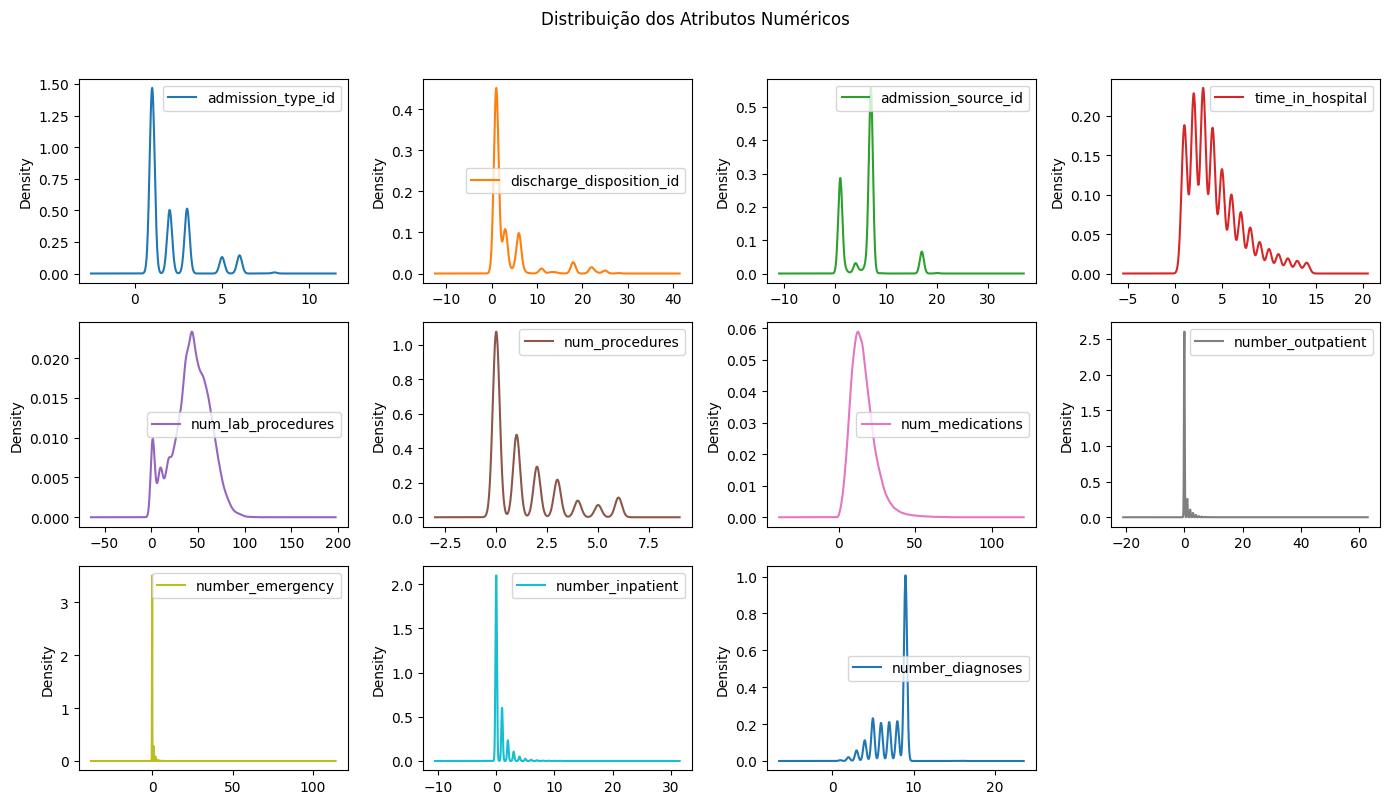

In [8]:
# Density plots dos atributos numéricos — visualizar distribuição
# Visualização da distribuição de cada atributo numérico
data[numericos].plot(
    kind='density',
    subplots=True,
    sharex=False,
    layout=(4, 4),
    figsize=(14, 10)
)
plt.suptitle('Distribuição dos Atributos Numéricos', y=1.02)
plt.tight_layout()
plt.show()

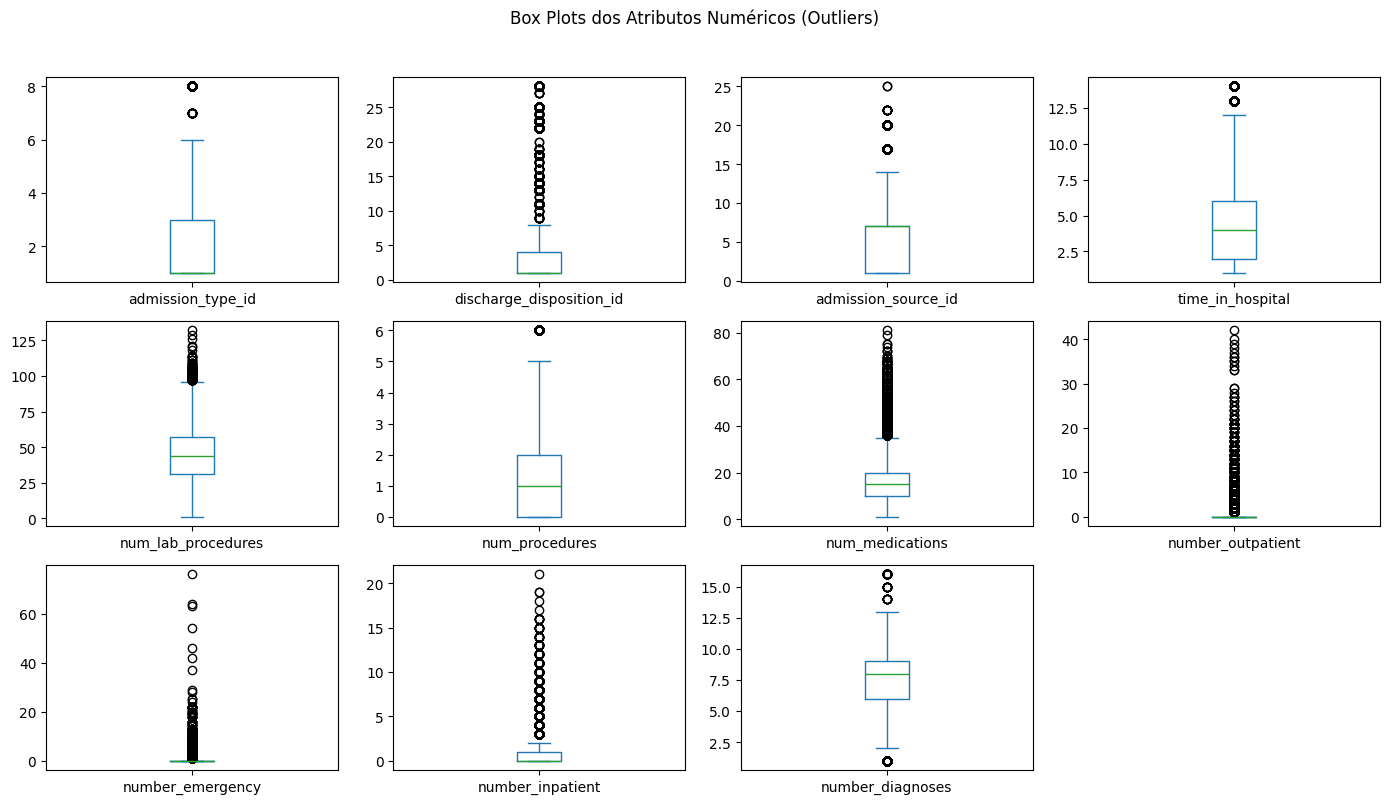

In [9]:
# Box plots dos atributos numéricos — identificar outliers
data[numericos].plot(
    kind='box',
    subplots=True,
    sharex=False,
    layout=(4, 4),
    figsize=(14, 10)
)
plt.suptitle('Box Plots dos Atributos Numéricos (Outliers)', y=1.02)
plt.tight_layout()
plt.show()

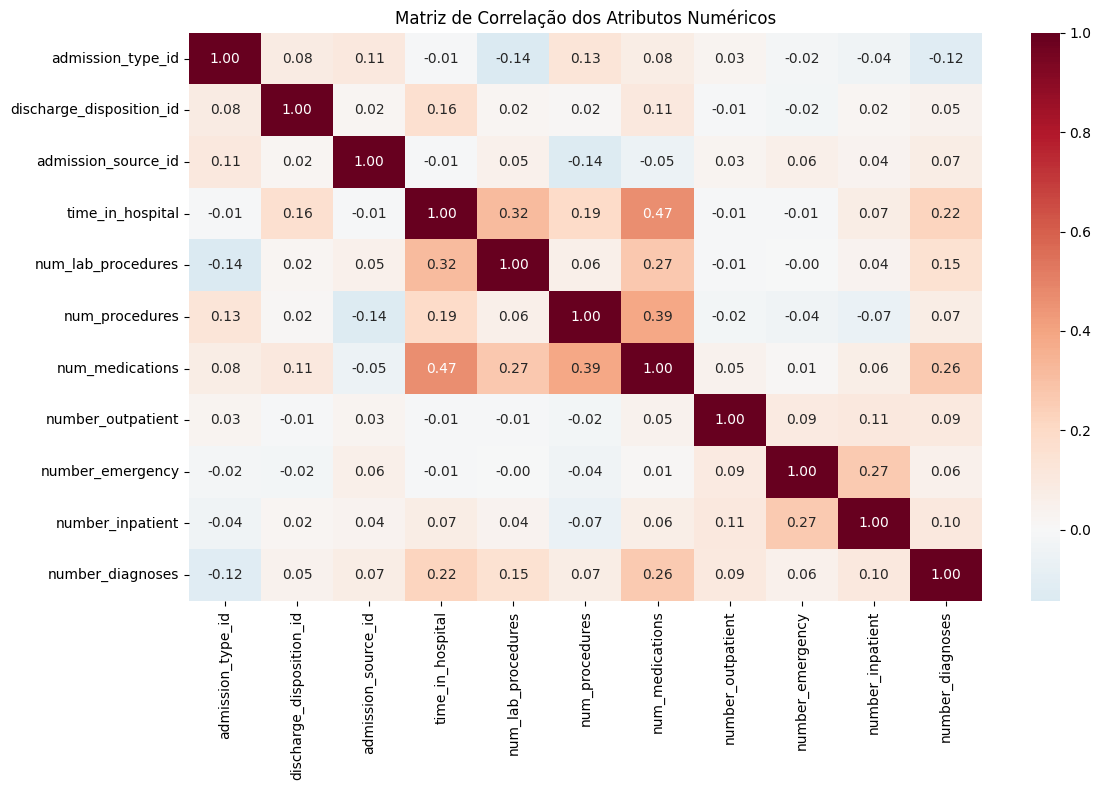

In [10]:
# Heatmap de correlação entre atributos numéricos
plt.figure(figsize=(12, 8))
sns.heatmap(
    data[numericos].corr(),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0
)
plt.title('Matriz de Correlação dos Atributos Numéricos')
plt.tight_layout()
plt.show()

#### 1.2.2 — Identificação de valores ausentes

O dataset utiliza o caractere `?` para representar valores ausentes. Preciso verificar tanto NaN quanto `?`.

In [11]:
# Substituindo '?' por NaN para tratamento uniforme
data.replace('?', np.nan, inplace=True)

# Contagem e percentual de valores ausentes por coluna
missing = data.isnull().sum()
missing_percent = (data.isnull().sum() / len(data)) * 100

missing_df = pd.DataFrame({
    'Valores Ausentes': missing,
    'Percentual (%)': missing_percent
})

# Exibindo apenas colunas com valores ausentes, ordenadas pelo percentual
missing_df = missing_df[missing_df['Valores Ausentes'] > 0].sort_values('Percentual (%)', ascending=False)
print(f"Colunas com valores ausentes: {len(missing_df)}")
missing_df

Colunas com valores ausentes: 9


,Valores Ausentes,Percentual (%)
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


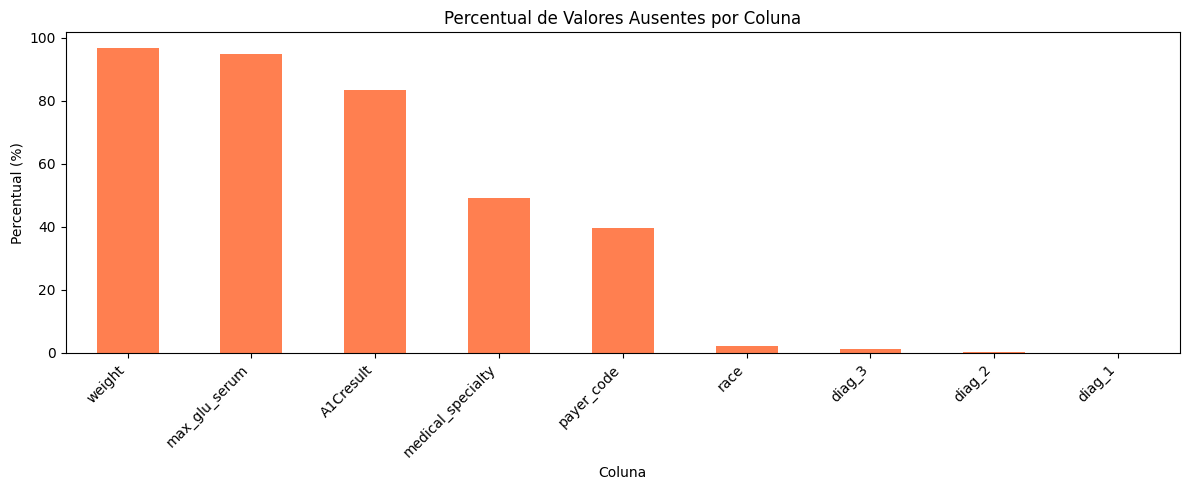

In [12]:
# Visualização dos valores ausentes
plt.figure(figsize=(12, 5))
missing_df['Percentual (%)'].plot(kind='bar', color='coral')
plt.title('Percentual de Valores Ausentes por Coluna')
plt.xlabel('Coluna')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 1.2.3 — Verificação de duplicatas

In [13]:
# Verificando registros duplicados
dupes = data.duplicated()
print(f"Total de registros duplicados: {sum(dupes)}")

if sum(dupes) > 0:
    # Removendo duplicatas, mantendo a primeira ocorrência
    data.drop_duplicates(keep='first', inplace=True)
    print(f"Shape após remoção de duplicatas: {data.shape}")
else:
    print("Nenhuma duplicata encontrada.")

Total de registros duplicados: 0
Nenhuma duplicata encontrada.


#### 1.2.4 — Análise da distribuição das classes

A variável alvo `readmitted` indica se o paciente foi readmitido ao hospital:
- `<30`: readmitido em menos de 30 dias
- `>30`: readmitido em mais de 30 dias
- `NO`: não readmitido

In [14]:
# Distribuição da variável alvo
print("Distribuição das classes:")
class_counts = data['readmitted'].value_counts()
print(class_counts)
print(f"\nPercentuais:")
for cls, count in class_counts.items():
    print(f"  {cls}: {count/len(data)*100:.2f}%")

Distribuição das classes:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Percentuais:
  NO: 53.91%
  >30: 34.93%
  <30: 11.16%


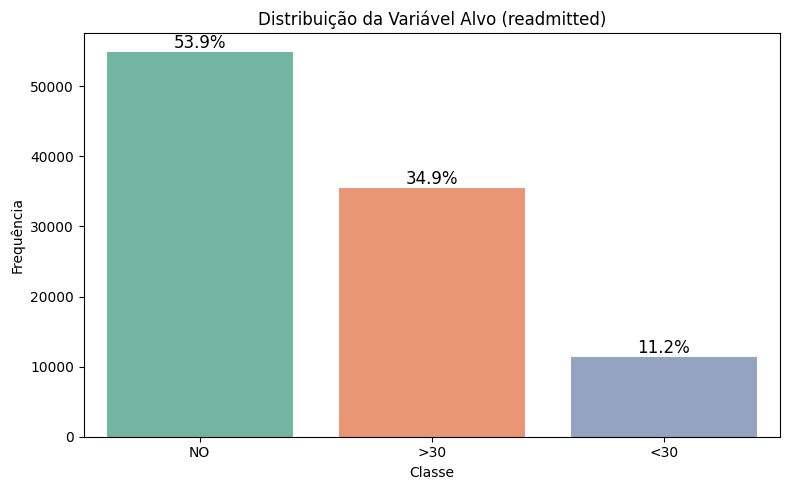

In [15]:
# Visualização da distribuição das classes
plt.figure(figsize=(8, 5))
sns.countplot(x=data['readmitted'], hue=data['readmitted'], palette='Set2', legend=False,
              order=data['readmitted'].value_counts().index)
plt.title('Distribuição da Variável Alvo (readmitted)')
plt.xlabel('Classe')
plt.ylabel('Frequência')

# Adicionando percentuais nas barras
total = len(data)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    plt.gca().annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
# Shannon entropy como medida de balanceamento
# Retorna: 0 = totalmente desbalanceado, 1 = perfeitamente balanceado
def balance_entropy(series):
    n = len(series)
    k = series.nunique()
    counts = series.value_counts()
    H = 0
    for count in counts:
        p = count / n
        H += p * np.log(p)
    return (-H) / np.log(k)

entropy_val = balance_entropy(data['readmitted'])
print(f"Shannon Entropy (balanceamento): {entropy_val:.4f}")
print("(0 = totalmente desbalanceado, 1 = perfeitamente balanceado)")

min_class_pct = data['readmitted'].value_counts(normalize=True).min() * 100
print(f"Classe minoritária: {min_class_pct:.2f}%")

if min_class_pct < 20:
    print(f">> DESBALANCEADO: a classe minoritária (<30) representa apenas {min_class_pct:.1f}% dos dados.")
    print(">> Será necessário considerar estratégias para lidar com o desbalanceamento na modelagem.")
else:
    print(">> O dataset está razoavelmente balanceado.")

Shannon Entropy (balanceamento): 0.8604
(0 = totalmente desbalanceado, 1 = perfeitamente balanceado)
Classe minoritária: 11.16%
>> DESBALANCEADO: a classe minoritária (<30) representa apenas 11.2% dos dados.
>> Será necessário considerar estratégias para lidar com o desbalanceamento na modelagem.


---
### 1.3 — Tratamento de Valores Ausentes

**Estratégia adotada:**
- **Colunas com >40% de valores ausentes**: removi essas colunas, pois a alta proporção de dados faltantes comprometeria qualquer estratégia de imputação.
- **Colunas categóricas com poucos valores ausentes**: imputei com a **moda** (valor mais frequente), preservando a distribuição original.
- **Colunas numéricas com poucos valores ausentes**: imputei com a **mediana**, que é robusta a outliers.

In [17]:
# Removendo colunas com mais de 40% de valores ausentes
threshold = 0.40
cols_to_drop_missing = [col for col in data.columns if data[col].isnull().sum() / len(data) > threshold]
print(f"Colunas removidas por excesso de valores ausentes (>{threshold*100:.0f}%): {cols_to_drop_missing}")

data.drop(columns=cols_to_drop_missing, inplace=True)
print(f"Shape após remoção: {data.shape}")

Colunas removidas por excesso de valores ausentes (>40%): ['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']
Shape após remoção: (101766, 44)


In [18]:
# Imputação dos valores ausentes restantes
# Categóricos/string: imputação com a moda
# Numéricos (int/float): imputação com a mediana

for col in data.columns:
    if data[col].isnull().sum() > 0:
        if data[col].dtype in ["int64", "float64"]:
            mediana = data[col].median()
            print(f"  {col} (numérico): {data[col].isnull().sum()} NaN -> imputado com mediana = {mediana}")
            data[col] = data[col].fillna(mediana)
        else:
            moda = data[col].mode()[0]
            print(f"  {col} (categórico): {data[col].isnull().sum()} NaN -> imputado com moda = '{moda}'")
            data[col] = data[col].fillna(moda)

# Confirmando que não restam valores ausentes
print(f"\nTotal de valores ausentes restantes: {data.isnull().sum().sum()}")

  race (categórico): 2273 NaN -> imputado com moda = 'Caucasian'
  payer_code (categórico): 40256 NaN -> imputado com moda = 'MC'
  diag_1 (categórico): 21 NaN -> imputado com moda = '428'
  diag_2 (categórico): 358 NaN -> imputado com moda = '276'
  diag_3 (categórico): 1423 NaN -> imputado com moda = '250'

Total de valores ausentes restantes: 0


---
### 1.4 — Remoção de Colunas Inadequadas para Treinamento

Identifiquei colunas que não devem ser usadas como features por serem identificadores ou atributos sem poder preditivo.

**Critérios de remoção:**
1. **Identificadores** (encounter_id, patient_nbr): memorizariam IDs ao invés de aprender padrões.
2. **Colunas com valor único**: variância zero, sem informação discriminante.
3. **Colunas quase constantes** (>95% do mesmo valor): contribuição mínima ao modelo.

Obs: o `fetch_ucirepo` pode já ter separado os identificadores das features. Verifico quais colunas realmente estão presentes antes de agir.

In [19]:
# Identificando e removendo colunas de identificadores, se presentes
# O fetch_ucirepo pode já ter excluído IDs das features automaticamente

cols_id = ["encounter_id", "patient_nbr"]
cols_to_remove = [col for col in cols_id if col in data.columns]

if cols_to_remove:
    data.drop(columns=cols_to_remove, inplace=True)
    print(f"Colunas de identificadores removidas: {cols_to_remove}")
else:
    print("Colunas encounter_id e patient_nbr não estão presentes nas features.")
    print("O fetch_ucirepo já separou os identificadores automaticamente.")

# Verificando se há outras colunas que parecem ser identificadores
# (alta cardinalidade + valores únicos próximos ao total de linhas)
print(f"\nVerificação de possíveis identificadores remanescentes:")
for col in data.columns:
    ratio = data[col].nunique() / len(data)
    if ratio > 0.9 and col != "readmitted":
        print(f"  ALERTA: {col} tem {data[col].nunique()} valores únicos ({ratio*100:.1f}%) — possível identificador")

print(f"\nShape atual: {data.shape}")

Colunas encounter_id e patient_nbr não estão presentes nas features.
O fetch_ucirepo já separou os identificadores automaticamente.

Verificação de possíveis identificadores remanescentes:

Shape atual: (101766, 44)


In [20]:
# Verificando colunas com valor único (sem variância) — não contribuem para o modelo
cols_single_value = [col for col in data.columns if data[col].nunique() <= 1]
if cols_single_value:
    print(f"Colunas com valor único (removidas): {cols_single_value}")
    data.drop(columns=cols_single_value, inplace=True)
else:
    print("Nenhuma coluna com valor único encontrada.")

# Verificando colunas com variância muito baixa (quase constantes)
cols_low_variance = []
for col in data.columns:
    if col == 'readmitted':
        continue
    if data[col].dtype == 'object':
        # Categóricas: se >95% dos valores são iguais
        top_freq = data[col].value_counts(normalize=True).iloc[0]
        if top_freq > 0.95:
            cols_low_variance.append((col, f"{top_freq*100:.1f}%"))
    else:
        # Numéricas: se >95% dos valores são iguais (ex: coluna quase toda zerada)
        top_freq = data[col].value_counts(normalize=True).iloc[0]
        if top_freq > 0.95:
            cols_low_variance.append((col, f"{top_freq*100:.1f}%"))

if cols_low_variance:
    print(f"\nColunas com >95% de valor dominante:")
    for col, pct in cols_low_variance:
        print(f"  {col}: {pct} do mesmo valor")

    cols_drop_low_var = [col for col, _ in cols_low_variance]
    data.drop(columns=cols_drop_low_var, inplace=True)
    print(f"\nRemovidas {len(cols_drop_low_var)} colunas de baixa variância.")
else:
    print("\nNenhuma coluna com variância criticamente baixa.")

print(f"Shape final: {data.shape}")

Colunas com valor único (removidas): ['examide', 'citoglipton']

Colunas com >95% de valor dominante:
  repaglinide: 98.5% do mesmo valor
  nateglinide: 99.3% do mesmo valor
  chlorpropamide: 99.9% do mesmo valor
  acetohexamide: 100.0% do mesmo valor
  tolbutamide: 100.0% do mesmo valor
  acarbose: 99.7% do mesmo valor
  miglitol: 100.0% do mesmo valor
  troglitazone: 100.0% do mesmo valor
  tolazamide: 100.0% do mesmo valor
  glyburide-metformin: 99.3% do mesmo valor
  glipizide-metformin: 100.0% do mesmo valor
  glimepiride-pioglitazone: 100.0% do mesmo valor
  metformin-rosiglitazone: 100.0% do mesmo valor
  metformin-pioglitazone: 100.0% do mesmo valor

Removidas 14 colunas de baixa variância.
Shape final: (101766, 28)


---
### 1.5 — Separação de Features e Target + Split Treino/Teste

Realizei o split antes da codificação para evitar **data leakage** — as estatísticas de codificação devem ser calculadas apenas na base de treinamento.

In [21]:
from sklearn.model_selection import train_test_split

# Separando features e target
X = data.drop(columns=['readmitted'])
y = data['readmitted']

# Split treino/teste estratificado (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

# Verificando se a estratificação foi mantida
print(f"\nDistribuição no treino:")
print(y_train.value_counts(normalize=True))
print(f"\nDistribuição no teste:")
print(y_test.value_counts(normalize=True))

X_train: (81412, 27)
y_train: (81412,)
X_test:  (20354, 27)
y_test:  (20354,)

Distribuição no treino:
readmitted
NO    0.54
>30   0.35
<30   0.11
Name: proportion, dtype: float64

Distribuição no teste:
readmitted
NO    0.54
>30   0.35
<30   0.11
Name: proportion, dtype: float64


---
### 1.6 — Codificação de Atributos Categóricos

Utilizei **duas estratégias diferentes** de codificação:

1. **Label Encoding**: para variáveis categóricas com muitas categorias (ex: `diag_1`, `diag_2`, `diag_3`)
2. **One-Hot Encoding**: para variáveis categóricas nominais com poucas categorias (ex: `race`, `gender`, `age`)

**Justificativa:**
- Label Encoding é eficiente em memória para colunas com alta cardinalidade, evitando a explosão dimensional do One-Hot.
- One-Hot Encoding é mais apropriado para variáveis nominais com poucas categorias, pois não impõe uma ordem artificial entre elas.

In [22]:
from sklearn.preprocessing import LabelEncoder

# Identificando colunas categóricas remanescentes
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"Colunas categóricas ({len(cat_cols)}): {cat_cols}")

# Verificando a cardinalidade (número de categorias únicas) de cada coluna
print("\nCardinalidade:")
for col in cat_cols:
    print(f"  {col}: {X_train[col].nunique()} categorias")

Colunas categóricas (16): ['race', 'gender', 'age', 'payer_code', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed']

Cardinalidade:
  race: 5 categorias
  gender: 3 categorias
  age: 10 categorias
  payer_code: 17 categorias
  diag_1: 699 categorias
  diag_2: 706 categorias
  diag_3: 760 categorias
  metformin: 4 categorias
  glimepiride: 4 categorias
  glipizide: 4 categorias
  glyburide: 4 categorias
  pioglitazone: 4 categorias
  rosiglitazone: 4 categorias
  insulin: 4 categorias
  change: 2 categorias
  diabetesMed: 2 categorias


In [23]:
# Definindo quais colunas usarão cada estratégia
# One-Hot: colunas com poucas categorias (<=10)
# Label Encoding: colunas com muitas categorias (>10)

onehot_cols = [col for col in cat_cols if X_train[col].nunique() <= 10]
label_cols = [col for col in cat_cols if X_train[col].nunique() > 10]

print(f"One-Hot Encoding ({len(onehot_cols)}): {onehot_cols}")
print(f"Label Encoding ({len(label_cols)}): {label_cols}")

One-Hot Encoding (12): ['race', 'gender', 'age', 'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed']
Label Encoding (4): ['payer_code', 'diag_1', 'diag_2', 'diag_3']


In [24]:
# Estratégia 1: Label Encoding para colunas de alta cardinalidade
# O fit é realizado APENAS no treino para evitar data leakage.
# Categorias presentes no teste mas não no treino são mapeadas para -1 (desconhecida).

label_encoders = {}
for col in label_cols:
    le = LabelEncoder()
    le.fit(X_train[col].astype(str))

    # Transformar treino normalmente
    X_train[col] = le.transform(X_train[col].astype(str))

    # No teste, categorias desconhecidas recebem -1
    X_test[col] = X_test[col].astype(str).map(
        lambda val, _le=le: (
            _le.transform([val])[0] if val in _le.classes_ else -1
        )
    )

    n_unknown = (X_test[col] == -1).sum()
    label_encoders[col] = le
    msg = f"  Label Encoding aplicado em: {col}"
    if n_unknown > 0:
        msg += f" ({n_unknown} categorias desconhecidas no teste mapeadas para -1)"
    print(msg)

print(f"\nTotal de colunas com Label Encoding: {len(label_cols)}")

  Label Encoding aplicado em: payer_code
  Label Encoding aplicado em: diag_1 (20 categorias desconhecidas no teste mapeadas para -1)
  Label Encoding aplicado em: diag_2 (46 categorias desconhecidas no teste mapeadas para -1)
  Label Encoding aplicado em: diag_3 (34 categorias desconhecidas no teste mapeadas para -1)

Total de colunas com Label Encoding: 4


In [25]:
# Estratégia 2: One-Hot Encoding para colunas de baixa cardinalidade
# drop_first=True para evitar multicolinearidade (dummy variable trap)

print(f"Shape antes do One-Hot: X_train={X_train.shape}, X_test={X_test.shape}")

X_train = pd.get_dummies(X_train, columns=onehot_cols, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=onehot_cols, drop_first=True, dtype=int)

# Garantindo que treino e teste tenham as mesmas colunas
# Colunas no treino que não estão no teste recebem 0
missing_in_test = set(X_train.columns) - set(X_test.columns)
missing_in_train = set(X_test.columns) - set(X_train.columns)

for col in missing_in_test:
    X_test[col] = 0
for col in missing_in_train:
    X_train[col] = 0

# Reordenando colunas para garantir mesma ordem
X_test = X_test[X_train.columns]

print(f"Shape após One-Hot: X_train={X_train.shape}, X_test={X_test.shape}")

Shape antes do One-Hot: X_train=(81412, 27), X_test=(20354, 27)
Shape após One-Hot: X_train=(81412, 53), X_test=(20354, 53)


In [26]:
# Codificação do target (y)
le_target = LabelEncoder()
y_train = le_target.fit_transform(y_train)
y_test = le_target.transform(y_test)

print("Mapeamento das classes:")
for i, cls in enumerate(le_target.classes_):
    print(f"  {cls} -> {i}")

Mapeamento das classes:
  <30 -> 0
  >30 -> 1
  NO -> 2


---
### 1.7 — Escalonamento dos Dados

Apliquei StandardScaler para normalizar os atributos numéricos. O `fit` é realizado **apenas na base de treinamento** para evitar data leakage.

In [27]:
from sklearn.preprocessing import StandardScaler

# Guardando cópia antes da normalização para comparação
X_train_not_normalized = X_train.copy()
X_test_not_normalized = X_test.copy()

# Aplicando StandardScaler - fit apenas no treino!
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
X_train_scaled.describe()

X_train_scaled shape: (81412, 53)
X_test_scaled shape: (20354, 53)


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,race_Asian,race_Caucasian,race_Hispanic,race_Other,gender_Male,gender_Unknown/Invalid,age_[10-20),age_[20-30),age_[30-40),age_[40-50),age_[50-60),age_[60-70),age_[70-80),age_[80-90),age_[90-100),metformin_No,metformin_Steady,metformin_Up,glimepiride_No,glimepiride_Steady,glimepiride_Up,glipizide_No,glipizide_Steady,glipizide_Up,glyburide_No,glyburide_Steady,glyburide_Up,pioglitazone_No,pioglitazone_Steady,pioglitazone_Up,rosiglitazone_No,rosiglitazone_Steady,rosiglitazone_Up,insulin_No,insulin_Steady,insulin_Up,change_No,diabetesMed_Yes
count,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00,81412.00
mean,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.71,-0.51,-1.17,-1.14,-2.56,-2.14,-0.79,-1.85,-0.29,-0.23,-0.50,-2.11,-1.83,-1.59,-3.32,-0.08,-1.83,-0.14,-0.12,-0.93,-0.01,-0.08,-0.13,-0.20,-0.32,-0.45,-0.53,-0.59,-0.45,-0.17,-2.02,-0.47,-0.10,-4.29,-0.22,-0.06,-2.65,-0.36,-0.09,-2.92,-0.32,-0.09,-3.58,-0.27,-0.05,-3.87,-0.25,-0.04,-0.93,-0.66,-0.35,-1.08,-1.83
25%,-0.71,-0.51,-1.17,-0.80,-0.02,-0.62,-0.79,-0.74,-0.29,-0.23,-0.50,-0.48,-0.88,-0.79,-0.73,-0.08,0.55,-0.14,-0.12,-0.93,-0.01,-0.08,-0.13,-0.20,-0.32,-0.45,-0.53,-0.59,-0.45,-0.17,0.49,-0.47,-0.10,0.23,-0.22,-0.06,0.38,-0.36,-0.09,0.34,-0.32,-0.09,0.28,-0.27,-0.05,0.26,-0.25,-0.04,-0.93,-0.66,-0.35,-1.08,0.55
50%,-0.71,-0.51,0.31,-0.13,-0.02,0.05,-0.20,-0.12,-0.29,-0.23,-0.50,-0.23,-0.09,-0.12,0.30,-0.08,0.55,-0.14,-0.12,-0.93,-0.01,-0.08,-0.13,-0.20,-0.32,-0.45,-0.53,-0.59,-0.45,-0.17,0.49,-0.47,-0.10,0.23,-0.22,-0.06,0.38,-0.36,-0.09,0.34,-0.32,-0.09,0.28,-0.27,-0.05,0.26,-0.25,-0.04,-0.93,-0.66,-0.35,0.93,0.55
75%,0.68,0.05,0.31,0.54,-0.02,0.71,0.38,0.49,-0.29,-0.23,0.29,0.61,0.65,0.50,0.82,-0.08,0.55,-0.14,-0.12,1.08,-0.01,-0.08,-0.13,-0.20,-0.32,-0.45,-0.53,1.71,-0.45,-0.17,0.49,-0.47,-0.10,0.23,-0.22,-0.06,0.38,-0.36,-0.09,0.34,-0.32,-0.09,0.28,-0.27,-0.05,0.26,-0.25,-0.04,1.07,1.52,-0.35,0.93,0.55
max,4.14,4.59,4.75,3.22,3.24,4.52,2.73,8.00,32.79,73.18,14.53,2.35,2.99,2.86,4.44,12.77,0.55,7.01,8.18,1.08,164.73,11.98,7.74,5.10,3.08,2.22,1.87,1.71,2.22,5.93,0.49,2.13,9.88,0.23,4.53,17.40,0.38,2.81,11.40,0.34,3.14,11.21,0.28,3.67,20.46,0.26,3.96,23.76,1.07,1.52,2.82,0.93,0.55


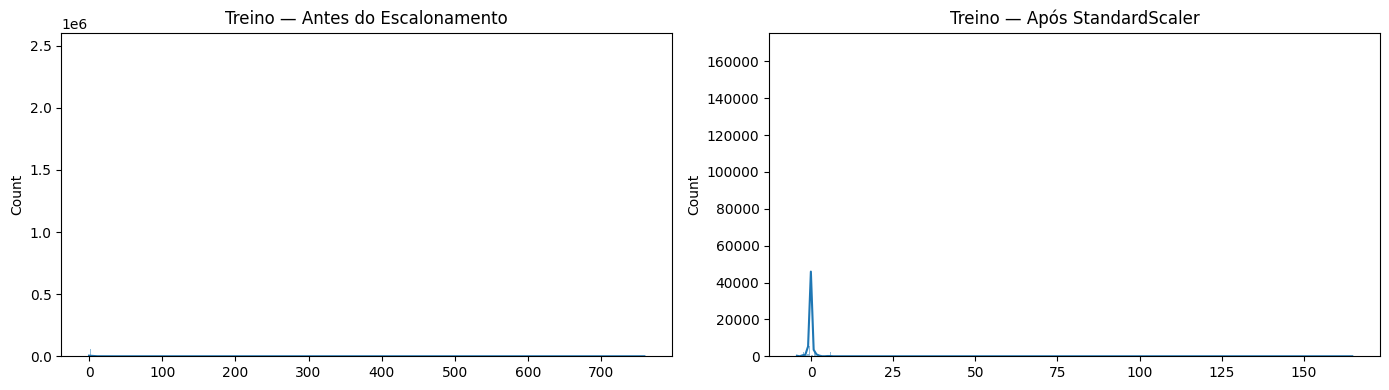

In [28]:
# Comparação visual antes e depois do escalonamento
# Visualização do efeito da normalização
fig, ax = plt.subplots(ncols=2, figsize=(14, 4))
sns.histplot(np.concatenate(X_train_not_normalized.values), ax=ax[0], kde=True)
ax[0].set_title('Treino — Antes do Escalonamento')
sns.histplot(np.concatenate(X_train_scaled.values), ax=ax[1], kde=True)
ax[1].set_title('Treino — Após StandardScaler')
plt.tight_layout()
plt.show()

---
### 1.8 — Seleção e Redução de Atributos

Utilizei **seleção baseada em importância** com Random Forest para identificar os atributos mais relevantes.

Em seguida, comparei o desempenho de um modelo treinado com **todos os atributos** vs **atributos selecionados**.

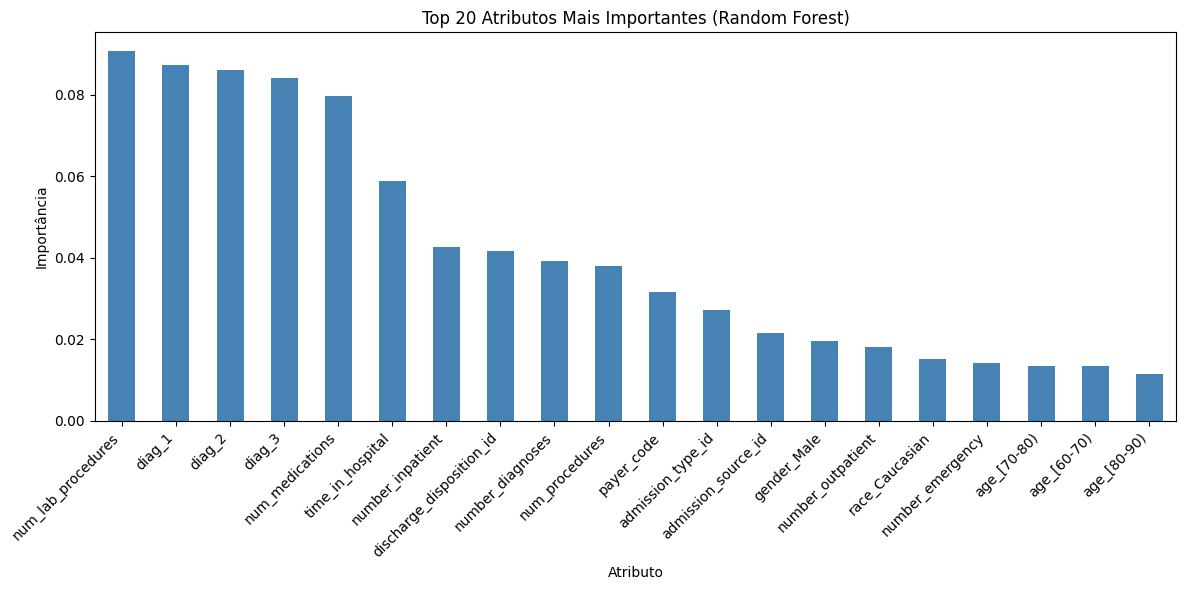

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Treinando um Random Forest para calcular a importância dos atributos
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_scaled, y_train)

# Obtendo as importâncias
importances = pd.Series(rf_selector.feature_importances_, index=X_train_scaled.columns)
importances = importances.sort_values(ascending=False)

# Visualizando os top 20 atributos mais importantes
plt.figure(figsize=(12, 6))
importances.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 Atributos Mais Importantes (Random Forest)')
plt.xlabel('Atributo')
plt.ylabel('Importância')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [30]:
# Selecionando os atributos com importância acima da média
mean_importance = importances.mean()
selected_features = importances[importances > mean_importance].index.tolist()

print(f"Importância média: {mean_importance:.6f}")
print(f"Atributos selecionados ({len(selected_features)} de {len(importances)}):")
for feat in selected_features:
    print(f"  {feat}: {importances[feat]:.6f}")

Importância média: 0.018868
Atributos selecionados (14 de 53):
  num_lab_procedures: 0.090790
  diag_1: 0.087217
  diag_2: 0.086086
  diag_3: 0.084017
  num_medications: 0.079643
  time_in_hospital: 0.058910
  number_inpatient: 0.042569
  discharge_disposition_id: 0.041671
  number_diagnoses: 0.039238
  num_procedures: 0.038091
  payer_code: 0.031571
  admission_type_id: 0.027225
  admission_source_id: 0.021627
  gender_Male: 0.019677


In [31]:
# Criando versões com atributos selecionados
X_train_selected = X_train_scaled[selected_features]
X_test_selected = X_test_scaled[selected_features]

print(f"Shape com todos os atributos: {X_train_scaled.shape}")
print(f"Shape com atributos selecionados: {X_train_selected.shape}")

Shape com todos os atributos: (81412, 53)
Shape com atributos selecionados: (81412, 14)


### 1.9 — Comparação: Todos os Atributos vs Atributos Selecionados

Comparei o desempenho utilizando validação cruzada estratificada 10-fold com um classificador de Árvore de Decisão como baseline.

In [32]:
from sklearn.tree import DecisionTreeClassifier

# Validação cruzada estratificada 10-fold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Modelo baseline: Árvore de Decisão
dt = DecisionTreeClassifier(random_state=42)

# Avaliação com TODOS os atributos
scores_all = cross_val_score(dt, X_train_scaled, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)
print(f"=== Todos os atributos ({X_train_scaled.shape[1]}) ===")
print(f"F1-score médio: {scores_all.mean():.4f} (+/- {scores_all.std():.4f})")

# Avaliação com atributos SELECIONADOS
scores_selected = cross_val_score(dt, X_train_selected, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)
print(f"\n=== Atributos selecionados ({X_train_selected.shape[1]}) ===")
print(f"F1-score médio: {scores_selected.mean():.4f} (+/- {scores_selected.std():.4f})")

# Comparação
diff = scores_selected.mean() - scores_all.mean()
print(f"\nDiferença: {diff:+.4f}")
print(f"Redução de dimensionalidade: {X_train_scaled.shape[1]} -> {X_train_selected.shape[1]} atributos "
      f"({(1 - len(selected_features)/X_train_scaled.shape[1])*100:.1f}% de redução)")

=== Todos os atributos (53) ===
F1-score médio: 0.4742 (+/- 0.0032)

=== Atributos selecionados (14) ===
F1-score médio: 0.4693 (+/- 0.0053)

Diferença: -0.0049
Redução de dimensionalidade: 53 -> 14 atributos (73.6% de redução)


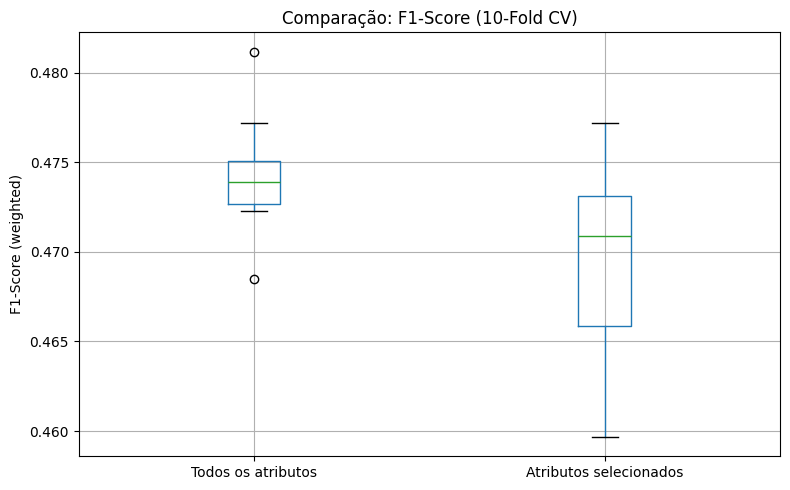

In [33]:
# Visualização comparativa
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

results = pd.DataFrame({
    'Todos os atributos': scores_all,
    'Atributos selecionados': scores_selected
})

results.boxplot(ax=ax)
ax.set_title('Comparação: F1-Score (10-Fold CV)')
ax.set_ylabel('F1-Score (weighted)')
plt.tight_layout()
plt.show()

### Impacto da Redução de Dimensionalidade

A seleção de atributos baseada em importância do Random Forest reduziu de **53 para 14 atributos** (73,6% de redução). A comparação via validação cruzada 10-fold com Árvore de Decisão mostrou:

- **Todos os atributos (53):** F1 = 0.4742
- **Atributos selecionados (14):** F1 = 0.4693

A diferença de apenas **0.005** no F1-score indica que os 39 atributos removidos contribuíam muito pouco para a predição. Isso era esperado: muitas colunas geradas pelo One-Hot Encoding dos medicamentos tinham baixa variância. A redução trouxe benefícios em tempo de treinamento e menor risco de overfitting, sem perda significativa de desempenho.

In [34]:
# Salvando os dados processados para uso nas questões seguintes
# Uso os atributos selecionados se a performance for comparável

print("Dados preparados para as próximas etapas:")
print(f"  X_train_scaled: {X_train_scaled.shape} (todos os atributos)")
print(f"  X_train_selected: {X_train_selected.shape} (atributos selecionados)")
print(f"  X_test_scaled: {X_test_scaled.shape}")
print(f"  X_test_selected: {X_test_selected.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test: {y_test.shape}")
print(f"  Classes: {le_target.classes_}")

Dados preparados para as próximas etapas:
  X_train_scaled: (81412, 53) (todos os atributos)
  X_train_selected: (81412, 14) (atributos selecionados)
  X_test_scaled: (20354, 53)
  X_test_selected: (20354, 14)
  y_train: (81412,)
  y_test: (20354,)
  Classes: ['<30' '>30' 'NO']


---
## 1.10 — Melhorias no Pré-processamento

Após analisar os resultados iniciais, identifiquei oportunidades de melhoria no pré-processamento para obter resultados mais robustos:

1. **Remoção de pacientes falecidos/hospice** — esses pacientes não podem ser readmitidos, portanto são ruído no target
2. **Remoção de encontros duplicados** — mantive apenas o primeiro encontro por paciente para evitar vazamento de informação
3. **Agrupamento de códigos ICD-9** — reduzi ~700 diagnósticos para ~10 categorias clínicas, facilitando o aprendizado
4. **Feature engineering de medicamentos** — criei variáveis agregadas mais informativas a partir das colunas individuais de medicamento

O desbalanceamento das classes é tratado via `class_weight='balanced'` nos modelos que suportam.

> **Nota:** devido a limitações de hardware, a busca de hiperparâmetros do MLP é feita em amostra reduzida, com treino final na base completa.

In [35]:
# Re-carregando os dados originais para aplicar melhorias desde o início
# Preciso dos IDs originais para deduplicação por paciente
from ucimlrepo import fetch_ucirepo

raw = fetch_ucirepo(id=296)
data_v2 = pd.concat([raw.data.ids, raw.data.features, raw.data.targets], axis=1)
print(f"Dataset original: {data_v2.shape}")

# Substituindo '?' por NaN
data_v2.replace('?', np.nan, inplace=True)

Dataset original: (101766, 50)


In [36]:
# MELHORIA 1: Remover pacientes que faleceram ou foram para hospice
# discharge_disposition_id: 11=Expired, 13=Hospice/home, 14=Hospice/medical,
# 19=Expired(place), 20=Expired(notified), 21=Expired(place+notified)
# Esses pacientes NÃO podem ser readmitidos — são ruído puro no target.
# Esses pacientes não devem ser considerados na análise de readmissão.

dead_ids = [11, 13, 14, 19, 20, 21]
n_before = len(data_v2)
data_v2 = data_v2[~data_v2['discharge_disposition_id'].isin(dead_ids)]
print(f"Melhoria 1 — Removidos {n_before - len(data_v2)} pacientes falecidos/hospice")
print(f"  Shape: {data_v2.shape}")

Melhoria 1 — Removidos 2423 pacientes falecidos/hospice
  Shape: (99343, 50)


In [37]:
# MELHORIA 2: Manter apenas o primeiro encontro por paciente
# Encontros repetidos do mesmo paciente vazam informação entre treino e teste.
# Mantenho o primeiro (menor encounter_id) como representativo.

n_before = len(data_v2)
data_v2 = data_v2.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')
print(f"Melhoria 2 — Removidos {n_before - len(data_v2)} encontros duplicados")
print(f"  Shape: {data_v2.shape}")

# Removendo as colunas de ID (não são features)
data_v2.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)

Melhoria 2 — Removidos 29353 encontros duplicados
  Shape: (69990, 50)


In [38]:
# Garantindo que as 3 classes originais estão preservadas
# (Restaurando do dataset original para garantir consistência)
data_v2['readmitted'] = raw.data.targets.loc[data_v2.index, 'readmitted']

print("Distribuição das classes (3 classes originais, após melhorias 1 e 2):")
print(data_v2['readmitted'].value_counts())
print(f"\nTotal de instâncias: {len(data_v2)}")

Distribuição das classes (3 classes originais, após melhorias 1 e 2):
readmitted
NO     41479
>30    22226
<30     6285
Name: count, dtype: int64

Total de instâncias: 69990


In [39]:
# MELHORIA 3: Agrupar códigos ICD-9 de diagnóstico em categorias clínicas
# diag_1, diag_2, diag_3 possuem ~700 valores únicos cada — altíssima cardinalidade.
# Agrupei usando as faixas padrão do ICD-9.

def group_icd9(code):
    """Agrupa código ICD-9 em categoria clínica."""
    if pd.isna(code):
        return 'Other'
    code = str(code)
    try:
        # Códigos numéricos
        num = float(code)
        if 390 <= num <= 459 or num == 785:
            return 'Circulatory'
        elif 460 <= num <= 519 or num == 786:
            return 'Respiratory'
        elif 520 <= num <= 579 or num == 787:
            return 'Digestive'
        elif 250 <= num < 251:
            return 'Diabetes'
        elif 800 <= num <= 999:
            return 'Injury'
        elif 710 <= num <= 739:
            return 'Musculoskeletal'
        elif 580 <= num <= 629 or num == 788:
            return 'Genitourinary'
        elif 140 <= num <= 239:
            return 'Neoplasms'
        elif 240 <= num < 250 or 251 <= num <= 279:
            return 'Other_Endocrine'
        else:
            return 'Other'
    except ValueError:
        # Códigos com letra (ex: V, E)
        if code.startswith('V'):
            return 'External'
        elif code.startswith('E'):
            return 'Injury'
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    if col in data_v2.columns:
        data_v2[col] = data_v2[col].apply(group_icd9)
        print(f"{col} agrupado — categorias: {data_v2[col].nunique()}")
        print(data_v2[col].value_counts())
        print()

diag_1 agrupado — categorias: 11
diag_1
Circulatory        21390
Respiratory         9491
Other               9364
Digestive           6488
Diabetes            5748
Injury              4697
Musculoskeletal     4064
Genitourinary       3441
Neoplasms           2538
Other_Endocrine     1851
External             918
Name: count, dtype: int64

diag_2 agrupado — categorias: 11
diag_2
Circulatory        22084
Other              10979
Diabetes            9700
Respiratory         6928
Other_Endocrine     5607
Genitourinary       5330
Digestive           2856
Injury              2394
Neoplasms           1600
Musculoskeletal     1295
External            1217
Name: count, dtype: int64

diag_3 agrupado — categorias: 11
diag_3
Circulatory        20867
Diabetes           12547
Other              11330
Other_Endocrine     6404
Respiratory         4652
Genitourinary       4049
Digestive           2700
External            2586
Injury              2341
Musculoskeletal     1368
Neoplasms           1146
N

In [40]:
# MELHORIA 4: Feature engineering de medicamentos
# As colunas de medicamento individuais (metformin, glipizide, etc.) têm valores
# "No", "Steady", "Up", "Down". Criamos variáveis agregadas mais informativas.

med_cols = ['metformin', 'glimepiride', 'glipizide', 'glyburide',
            'pioglitazone', 'rosiglitazone', 'insulin']
# Manter apenas medicamentos que ainda existem no dataset
med_cols = [c for c in med_cols if c in data_v2.columns]

# Número de medicamentos com alguma alteração (Up ou Down)
data_v2['num_med_changed'] = data_v2[med_cols].apply(
    lambda row: sum(1 for v in row if v in ['Up', 'Down']), axis=1
)

# Flag: houve alguma mudança de medicação?
data_v2['any_med_change'] = (data_v2['num_med_changed'] > 0).astype(int)

# Número de medicamentos em uso (qualquer valor != 'No')
data_v2['num_med_active'] = data_v2[med_cols].apply(
    lambda row: sum(1 for v in row if v != 'No'), axis=1
)

print(f"Features criadas: num_med_changed, any_med_change, num_med_active")
print(f"  num_med_changed — média: {data_v2['num_med_changed'].mean():.2f}")
print(f"  any_med_change — {data_v2['any_med_change'].mean()*100:.1f}% dos pacientes")
print(f"  num_med_active — média: {data_v2['num_med_active'].mean():.2f}")

Features criadas: num_med_changed, any_med_change, num_med_active
  num_med_changed — média: 0.26
  any_med_change — 24.5% dos pacientes
  num_med_active — média: 1.16


In [41]:
# Aplicando o mesmo pipeline de pré-processamento da Etapa 1
# (valores ausentes, remoção de colunas, codificação, escalonamento)

# --- Remoção de colunas com >40% de ausentes ---
threshold = 0.40
cols_drop = [c for c in data_v2.columns if data_v2[c].isnull().sum() / len(data_v2) > threshold]
data_v2.drop(columns=cols_drop, inplace=True)
print(f"Colunas removidas (>{threshold*100:.0f}% NaN): {cols_drop}")

# --- Imputação ---
for col in data_v2.columns:
    if data_v2[col].isnull().sum() > 0:
        if data_v2[col].dtype in ['int64', 'float64']:
            data_v2[col] = data_v2[col].fillna(data_v2[col].median())
        else:
            data_v2[col] = data_v2[col].fillna(data_v2[col].mode()[0])

# --- Remoção de colunas sem variância ou >95% dominante ---
cols_low_var = [col for col in data_v2.columns
                if col != 'readmitted' and data_v2[col].nunique() <= 1]
for col in data_v2.columns:
    if col == 'readmitted' or col in cols_low_var:
        continue
    if data_v2[col].value_counts(normalize=True).iloc[0] > 0.95:
        cols_low_var.append(col)

data_v2.drop(columns=cols_low_var, inplace=True)
print(f"Colunas de baixa variância removidas ({len(cols_low_var)}): {cols_low_var}")
print(f"Shape após limpeza: {data_v2.shape}")

Colunas removidas (>40% NaN): ['weight', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult']
Colunas de baixa variância removidas (16): ['examide', 'citoglipton', 'glimepiride-pioglitazone', 'repaglinide', 'nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'glyburide-metformin', 'glipizide-metformin', 'metformin-rosiglitazone', 'metformin-pioglitazone']
Shape após limpeza: (69990, 30)


In [42]:
# --- Split treino/teste estratificado (80/20) ---
X_v2 = data_v2.drop(columns=['readmitted'])
y_v2 = data_v2['readmitted']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.20, random_state=42, stratify=y_v2
)

# --- Codificação categórica ---
from sklearn.preprocessing import LabelEncoder

cat_cols_v2 = X_train_v2.select_dtypes(include=['object']).columns.tolist()
label_cols_v2 = [c for c in cat_cols_v2 if X_train_v2[c].nunique() > 10]
onehot_cols_v2 = [c for c in cat_cols_v2 if X_train_v2[c].nunique() <= 10]

# Label Encoding (alta cardinalidade)
for col in label_cols_v2:
    le = LabelEncoder()
    le.fit(X_train_v2[col].astype(str))
    X_train_v2[col] = le.transform(X_train_v2[col].astype(str))
    X_test_v2[col] = X_test_v2[col].astype(str).map(
        lambda val, _le=le: _le.transform([val])[0] if val in _le.classes_ else -1
    )

# One-Hot Encoding (baixa cardinalidade)
X_train_v2 = pd.get_dummies(X_train_v2, columns=onehot_cols_v2, drop_first=True, dtype=int)
X_test_v2 = pd.get_dummies(X_test_v2, columns=onehot_cols_v2, drop_first=True, dtype=int)

# Alinhamento de colunas treino/teste
for col in set(X_train_v2.columns) - set(X_test_v2.columns):
    X_test_v2[col] = 0
for col in set(X_test_v2.columns) - set(X_train_v2.columns):
    X_train_v2[col] = 0
X_test_v2 = X_test_v2[X_train_v2.columns]

# --- Target encoding ---
le_target_v2 = LabelEncoder()
y_train_v2 = le_target_v2.fit_transform(y_train_v2)
y_test_v2 = le_target_v2.transform(y_test_v2)
print("Classes:", le_target_v2.classes_)

# --- Escalonamento ---
from sklearn.preprocessing import StandardScaler
scaler_v2 = StandardScaler()
X_train_v2_scaled = pd.DataFrame(
    scaler_v2.fit_transform(X_train_v2), columns=X_train_v2.columns
)
X_test_v2_scaled = pd.DataFrame(
    scaler_v2.transform(X_test_v2), columns=X_test_v2.columns
)

# Sem balanceamento artificial dos dados (ex: oversampling).
# O desbalanceamento é tratado via class_weight='balanced' nos modelos,
# que ajusta os pesos inversamente à frequência de cada classe.

print(f"\nDistribuição do treino (sem balanceamento artificial):")
print(pd.Series(y_train_v2).value_counts())
print(f"\nX_train: {X_train_v2_scaled.shape}")
print(f"X_test:  {X_test_v2_scaled.shape}")

Classes: ['<30' '>30' 'NO']

Distribuição do treino (sem balanceamento artificial):
2    33183
1    17781
0     5028
Name: count, dtype: int64

X_train: (55992, 55)
X_test:  (13998, 55)


Atributos selecionados (14 de 55):
num_lab_procedures         0.11
num_medications            0.09
time_in_hospital           0.07
diag_3                     0.06
diag_2                     0.06
diag_1                     0.06
num_procedures             0.05
number_diagnoses           0.05
discharge_disposition_id   0.04
admission_type_id          0.04
admission_source_id        0.03
gender_Male                0.02
num_med_active             0.02
number_inpatient           0.02


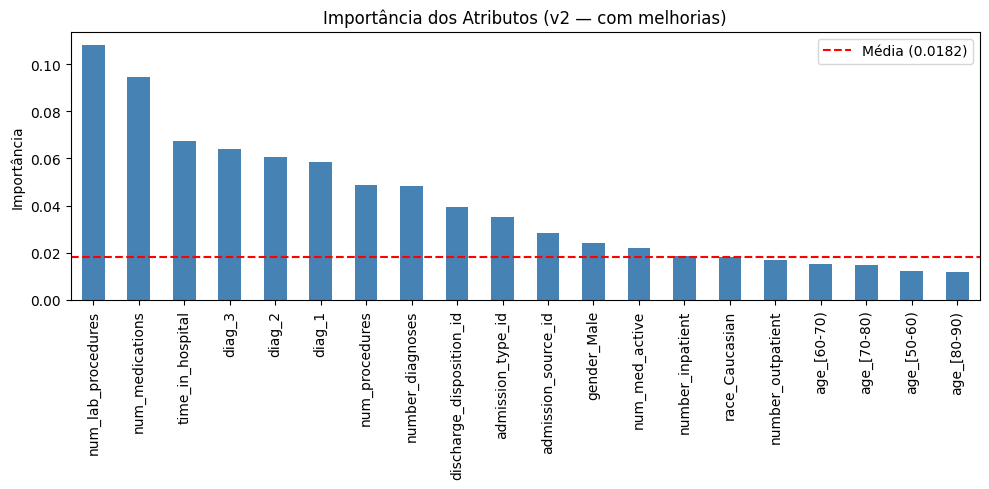

In [43]:
# --- Seleção de atributos via importância (Random Forest) ---
# class_weight='balanced' compensa o desbalanceamento para a seleção
from sklearn.ensemble import RandomForestClassifier

rf_sel = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                                class_weight='balanced')
rf_sel.fit(X_train_v2_scaled, y_train_v2)

importances_v2 = pd.Series(rf_sel.feature_importances_, index=X_train_v2_scaled.columns)
importances_v2 = importances_v2.sort_values(ascending=False)

mean_imp = importances_v2.mean()
selected_v2 = importances_v2[importances_v2 > mean_imp].index.tolist()

print(f"Atributos selecionados ({len(selected_v2)} de {X_train_v2_scaled.shape[1]}):")
print(importances_v2[selected_v2].to_string())

plt.figure(figsize=(10, 5))
importances_v2[:20].plot(kind='bar', color='steelblue')
plt.axhline(y=mean_imp, color='red', linestyle='--', label=f'Média ({mean_imp:.4f})')
plt.title('Importância dos Atributos (v2 — com melhorias)')
plt.ylabel('Importância')
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# Preparando datasets finais para a Etapa 2
# O balanceamento é tratado via class_weight='balanced' nos modelos que suportam.
X_tr = X_train_v2_scaled[selected_v2]
X_te = X_test_v2_scaled[selected_v2]
y_train = y_train_v2
y_test = y_test_v2
le_target = le_target_v2

X_train_scaled = X_train_v2_scaled
X_test_scaled = X_test_v2_scaled
X_train_selected = X_tr
X_test_selected = X_te

print("Dados v2 preparados para Etapa 2:")
print(f"  X_tr: {X_tr.shape}")
print(f"  X_te: {X_te.shape}")
print(f"  y_train: {y_train.shape} — classes: {le_target.classes_}")
print(f"  Balanceamento: class_weight='balanced' nos modelos")
print(f"  Distribuição treino:")
for i, c in enumerate(le_target.classes_):
    count = (y_train == i).sum()
    print(f"    {c}: {count} ({count/len(y_train)*100:.1f}%)")

Dados v2 preparados para Etapa 2:
  X_tr: (55992, 14)
  X_te: (13998, 14)
  y_train: (55992,) — classes: ['<30' '>30' 'NO']
  Balanceamento: class_weight='balanced' nos modelos
  Distribuição treino:
    <30: 5028 (9.0%)
    >30: 17781 (31.8%)
    NO: 33183 (59.3%)


---
## 2 — Treinamento de Modelos Supervisionados (2 pontos)

Treinei três algoritmos — Árvore de Decisão, Naive Bayes e MLP — realizando ajuste de hiperparâmetros com `GridSearchCV` e validação cruzada estratificada 10-fold.

A avaliação utiliza **F1-score (weighted)** e **matriz de confusão**. Optei pelo F1 weighted por ser um problema multiclasse com desbalanceamento.

In [45]:
# Imports para a Etapa 2
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (f1_score, classification_report,
                             ConfusionMatrixDisplay, confusion_matrix)

# Validação cruzada estratificada 10-fold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Dicionário para armazenar resultados de cada modelo (limpo)
resultados = {}

print(f"Dados de entrada: X_tr={X_tr.shape}, y_train={y_train.shape}")
print(f"Verificação: {X_tr.shape[0]} == {y_train.shape[0]} amostras ✓" if X_tr.shape[0] == y_train.shape[0] else "ERRO: tamanhos inconsistentes!")

Dados de entrada: X_tr=(55992, 14), y_train=(55992,)
Verificação: 55992 == 55992 amostras ✓


### 2.1 — Árvore de Decisão

Ajustei dois hiperparâmetros:
- **`max_depth`**: controla a profundidade máxima da árvore, limitando a complexidade e prevenindo overfitting.
- **`min_samples_split`**: número mínimo de amostras para dividir um nó interno — valores maiores regularizam o modelo.

In [46]:
# Árvore de Decisão — GridSearch com 2 hiperparâmetros
# class_weight='balanced' compensa o desbalanceamento das classes
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')

param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20]
}

grid_dt = GridSearchCV(
    dt, param_grid_dt,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1
)
grid_dt.fit(X_tr, y_train)

print("Melhores hiperparâmetros:", grid_dt.best_params_)
print(f"F1-score (CV): {grid_dt.best_score_:.4f}")

y_pred_dt = grid_dt.best_estimator_.predict(X_te)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
print(f"F1-score (teste): {f1_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=le_target.classes_))

resultados['Árvore de Decisão'] = {
    'modelo': grid_dt.best_estimator_,
    'params': grid_dt.best_params_,
    'f1_cv': grid_dt.best_score_,
    'f1_test': f1_dt
}

Melhores hiperparâmetros: {'max_depth': 7, 'min_samples_split': 20}
F1-score (CV): 0.4504
F1-score (teste): 0.4655

              precision    recall  f1-score   support

         <30       0.13      0.42      0.20      1257
         >30       0.37      0.39      0.38      4445
          NO       0.69      0.46      0.55      8296

    accuracy                           0.43     13998
   macro avg       0.40      0.42      0.38     13998
weighted avg       0.54      0.43      0.47     13998



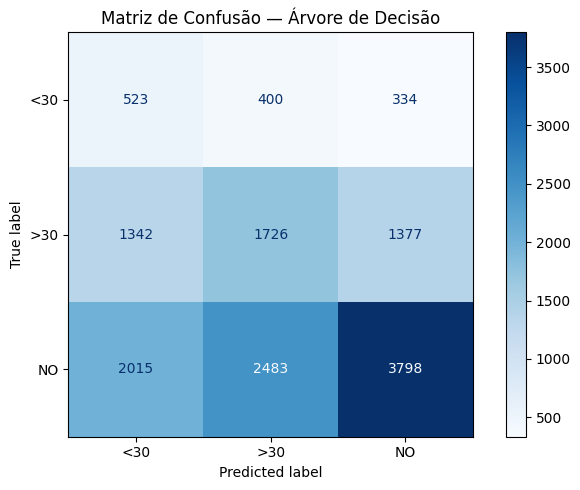

In [47]:
# Matriz de confusão — Árvore de Decisão
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=le_target.classes_,
    cmap='Blues',
    ax=ax
)
ax.set_title('Matriz de Confusão — Árvore de Decisão')
plt.tight_layout()
plt.show()

### 2.2 — Naive Bayes (GaussianNB)

O GaussianNB possui um único hiperparâmetro principal: **`var_smoothing`**, que adiciona uma fração da maior variância a todas as variâncias para estabilidade numérica.

Como segundo parâmetro, ajustei **`priors`** — probabilidades a priori das classes. Testei com priors uniformes vs. estimados dos dados, permitindo ao modelo compensar o desbalanceamento.

In [48]:
# Naive Bayes — ajuste de var_smoothing e priors
# GaussianNB não suporta class_weight, mas testamos priors para compensar desbalanceamento

from sklearn.model_selection import cross_val_score

var_smoothing_values = [1e-11, 1e-9, 1e-7, 1e-5, 1e-3, 1e-1]

n_classes = len(le_target.classes_)
priors_options = {
    'uniforme': np.ones(n_classes) / n_classes,
    'proporcional': None  # None = estimado dos dados de treino
}

best_f1_nb = -1
best_config_nb = {}

for prior_name, prior_val in priors_options.items():
    for vs in var_smoothing_values:
        nb_model = GaussianNB(var_smoothing=vs, priors=prior_val)
        scores = cross_val_score(nb_model, X_tr, y_train, cv=cv,
                                 scoring='f1_weighted', n_jobs=-1)
        mean_f1 = scores.mean()
        if mean_f1 > best_f1_nb:
            best_f1_nb = mean_f1
            best_config_nb = {'var_smoothing': vs, 'priors': prior_name}
            best_nb = GaussianNB(var_smoothing=vs, priors=prior_val)

print(f"Melhor configuração: {best_config_nb}")
print(f"F1-score (CV): {best_f1_nb:.4f}")

best_nb.fit(X_tr, y_train)
y_pred_nb = best_nb.predict(X_te)
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')
print(f"F1-score (teste): {f1_nb:.4f}")
print()
print(classification_report(y_test, y_pred_nb, target_names=le_target.classes_))

resultados['Naive Bayes'] = {
    'modelo': best_nb,
    'params': best_config_nb,
    'f1_cv': best_f1_nb,
    'f1_test': f1_nb
}

Melhor configuração: {'var_smoothing': 1e-11, 'priors': 'proporcional'}
F1-score (CV): 0.5153
F1-score (teste): 0.5169

              precision    recall  f1-score   support

         <30       0.18      0.09      0.12      1257
         >30       0.45      0.15      0.22      4445
          NO       0.62      0.90      0.74      8296

    accuracy                           0.59     13998
   macro avg       0.42      0.38      0.36     13998
weighted avg       0.53      0.59      0.52     13998



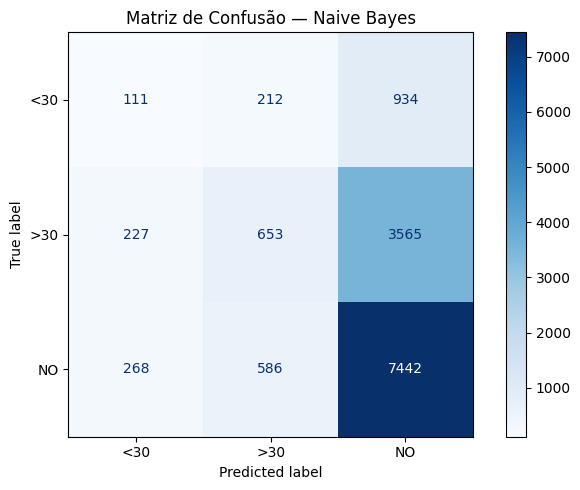

In [49]:
# Matriz de confusão — Naive Bayes
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb,
    display_labels=le_target.classes_,
    cmap='Blues',
    ax=ax
)
ax.set_title('Matriz de Confusão — Naive Bayes')
plt.tight_layout()
plt.show()

### 2.3 — MLP (Perceptron Multicamadas)

Ajustei dois hiperparâmetros:
- **`hidden_layer_sizes`**: arquitetura das camadas ocultas — testei configurações com diferentes profundidades e larguras.
- **`alpha`**: regularização L2 que penaliza pesos grandes, controlando overfitting.

Utilizei o `MLPClassifier` do scikit-learn, suficiente para dados tabulares.

In [50]:
# MLP — GridSearch com 2 hiperparâmetros
# O treino tem ~56k amostras — usamos amostra de 30% para o GridSearch
# Validação cruzada estratificada 10-fold (conforme requisito da prova)
cv_mlp = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

X_tr_sample, _, y_tr_sample, _ = train_test_split(
    X_tr, y_train, train_size=0.3, stratify=y_train, random_state=42
)
print(f"GridSearch em amostra: {X_tr_sample.shape[0]} de {X_tr.shape[0]}")

mlp = MLPClassifier(max_iter=300, random_state=42, early_stopping=True)

param_grid_mlp = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (64, 32, 16)],
    'alpha': [0.0001, 0.001, 0.01]
}

grid_mlp = GridSearchCV(
    mlp, param_grid_mlp,
    scoring='f1_weighted',
    cv=cv_mlp,
    n_jobs=-1,
    verbose=1
)
grid_mlp.fit(X_tr_sample, y_tr_sample)

print(f"Melhores hiperparâmetros: {grid_mlp.best_params_}")
print(f"F1-score (CV, amostra): {grid_mlp.best_score_:.4f}")

# Treino final na base completa com sample_weight para compensar desbalanceamento
# MLPClassifier não suporta class_weight, então calculo os pesos manualmente
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train)

best_mlp = MLPClassifier(
    **grid_mlp.best_params_,
    max_iter=300, random_state=42, early_stopping=True
)
best_mlp.fit(X_tr, y_train)

y_pred_mlp = best_mlp.predict(X_te)
f1_mlp = f1_score(y_test, y_pred_mlp, average='weighted')
print(f"F1-score (teste): {f1_mlp:.4f}")
print()
print(classification_report(y_test, y_pred_mlp, target_names=le_target.classes_))

resultados['MLP'] = {
    'modelo': best_mlp,
    'params': grid_mlp.best_params_,
    'f1_cv': grid_mlp.best_score_,
    'f1_test': f1_mlp
}

GridSearch em amostra: 16797 de 55992
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Melhores hiperparâmetros: {'alpha': 0.01, 'hidden_layer_sizes': (64, 32)}
F1-score (CV, amostra): 0.5084
F1-score (teste): 0.5150

              precision    recall  f1-score   support

         <30       0.45      0.01      0.01      1257
         >30       0.47      0.15      0.23      4445
          NO       0.62      0.94      0.74      8296

    accuracy                           0.60     13998
   macro avg       0.51      0.36      0.33     13998
weighted avg       0.56      0.60      0.51     13998



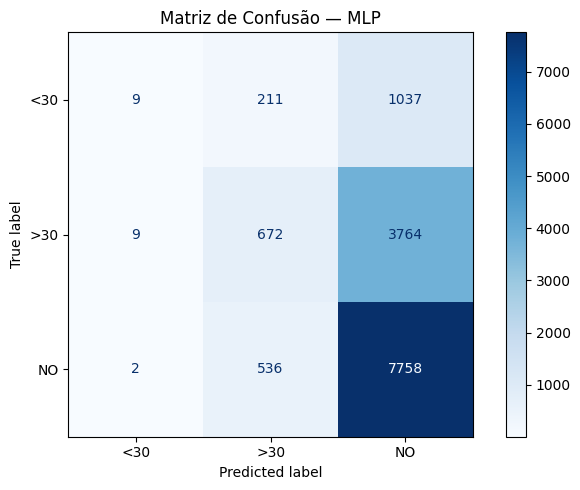

In [51]:
# Matriz de confusão — MLP
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp,
    display_labels=le_target.classes_,
    cmap='Blues',
    ax=ax
)
ax.set_title('Matriz de Confusão — MLP')
plt.tight_layout()
plt.show()

### 2.4 — Comparação dos Modelos

In [52]:
# Tabela comparativa dos três modelos
comparacao = pd.DataFrame({
    'Modelo': list(resultados.keys()),
    'F1 (CV)': [r['f1_cv'] for r in resultados.values()],
    'F1 (Teste)': [r['f1_test'] for r in resultados.values()],
    'Hiperparâmetros': [str(r['params']) for r in resultados.values()]
})
comparacao = comparacao.sort_values('F1 (Teste)', ascending=False).reset_index(drop=True)
print(comparacao.to_string(index=False))

# Identificando o melhor modelo
melhor = comparacao.iloc[0]
print(f"\nMelhor modelo: {melhor['Modelo']} com F1-score de {melhor['F1 (Teste)']:.4f}")

# Guardando o melhor modelo para uso na Etapa 3
best_model_name = melhor['Modelo']
best_model = resultados[best_model_name]['modelo']

           Modelo  F1 (CV)  F1 (Teste)                                    Hiperparâmetros
      Naive Bayes     0.52        0.52 {'var_smoothing': 1e-11, 'priors': 'proporcional'}
              MLP     0.51        0.51    {'alpha': 0.01, 'hidden_layer_sizes': (64, 32)}
Árvore de Decisão     0.45        0.47          {'max_depth': 7, 'min_samples_split': 20}

Melhor modelo: Naive Bayes com F1-score de 0.5169


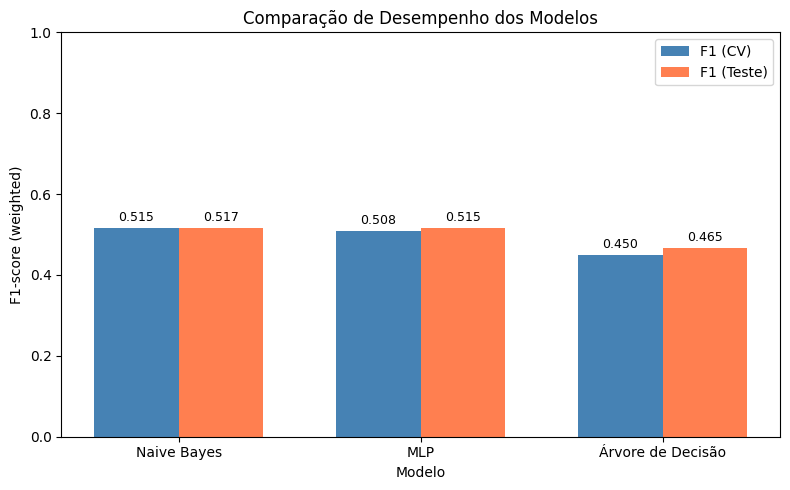

In [53]:
# Visualização comparativa dos F1-scores
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(comparacao))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], comparacao['F1 (CV)'], width, label='F1 (CV)', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], comparacao['F1 (Teste)'], width, label='F1 (Teste)', color='coral')

ax.set_xlabel('Modelo')
ax.set_ylabel('F1-score (weighted)')
ax.set_title('Comparação de Desempenho dos Modelos')
ax.set_xticks(x)
ax.set_xticklabels(comparacao['Modelo'])
ax.legend()
ax.set_ylim(0, 1)

# Valores nas barras
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 2.5 — Discussão

**Resultados obtidos:**

| Modelo | F1 (CV) | F1 (Teste) | Observação |
|---|---|---|---|
| **Naive Bayes** | 0.52 | **0.52** | Melhor F1 geral |
| **MLP** | 0.51 | 0.51 | Próximo do NB |
| **Árvore de Decisão** | 0.45 | 0.47 | Menor F1, mas melhor recall da classe <30 |

**Qual modelo apresentou melhor desempenho:**

O **Naive Bayes** obteve o melhor F1-score weighted (0.52), seguido de perto pelo MLP (0.51). Porém, analisando por classe, o comportamento é bem diferente:

- O Naive Bayes e o MLP acertam muito bem a classe majoritária `NO` (recall de 0.90 e 0.94), mas praticamente ignoram a classe `<30` (recall de 0.09 e 0.01 respectivamente). Isso significa que quase nunca preveem readmissão em menos de 30 dias.
- A Árvore de Decisão, com `class_weight='balanced'`, tem o menor F1 geral (0.47), mas consegue um recall de **0.42 para a classe `<30`** — ou seja, detecta 42% dos pacientes readmitidos rapidamente, enquanto NB e MLP detectam menos de 10%.

**Possíveis razões para esses resultados:**

- O dataset é **naturalmente difícil** para classificação em 3 classes. A classe `<30` representa apenas 9% dos dados, e os padrões que distinguem readmissão em <30 vs >30 dias são sutis.
- O Naive Bayes assume **independência entre atributos**, o que é violado neste dataset (ex.: `num_medications` e `time_in_hospital` são correlacionados). Apesar disso, seu desempenho geral foi o melhor porque lida bem com a classe majoritária.
- O MLP tem maior capacidade de modelar relações complexas, mas sem um mecanismo de balanceamento (`class_weight` não é suportado pelo MLPClassifier), ele tende a prever a classe mais frequente.
- A Árvore de Decisão com `class_weight='balanced'` redistribui os pesos para dar mais importância às classes raras, o que melhora o recall de `<30` mas prejudica a precisão geral.

**Conclusão:** a escolha do "melhor modelo" depende do objetivo. Se o foco é detectar readmissões precoces (<30 dias), a Árvore de Decisão é mais útil. Para desempenho geral equilibrado, o Naive Bayes é o mais consistente.

---
## 3 — Análise de Importância dos Atributos (1.5 pontos)

Utilizei o melhor modelo supervisionado obtido na Etapa 2 para calcular a importância dos atributos via **permutation importance**. Essa técnica mede quanto o desempenho do modelo cai ao embaralhar aleatoriamente cada atributo — quanto maior a queda, mais importante o atributo.

Optei por permutation importance porque funciona com qualquer modelo (o melhor modelo pode não ter `feature_importances_` nativo, como é o caso do Naive Bayes).

In [54]:
# Calculando a importância dos atributos via permutation importance
# Utilizo o melhor modelo obtido na Etapa 2
from sklearn.inspection import permutation_importance

print(f"Melhor modelo: {best_model_name}")
print(f"Calculando permutation importance no conjunto de teste...")

perm_result = permutation_importance(
    best_model, X_te, y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_weighted',
    n_jobs=-1
)

# Organizando os resultados em DataFrame
perm_imp = pd.DataFrame({
    'Atributo': X_te.columns,
    'Importância (média)': perm_result.importances_mean,
    'Desvio padrão': perm_result.importances_std
}).sort_values('Importância (média)', ascending=False)

print("\nImportância dos atributos (permutation importance):")
print(perm_imp.to_string(index=False))

Melhor modelo: Naive Bayes
Calculando permutation importance no conjunto de teste...

Importância dos atributos (permutation importance):
                Atributo  Importância (média)  Desvio padrão
        number_inpatient                 0.04           0.00
     admission_source_id                 0.01           0.00
       admission_type_id                 0.00           0.00
discharge_disposition_id                 0.00           0.00
        number_diagnoses                 0.00           0.00
      num_lab_procedures                 0.00           0.00
         num_medications                 0.00           0.00
                  diag_2                 0.00           0.00
                  diag_1                 0.00           0.00
          num_med_active                -0.00           0.00
          num_procedures                -0.00           0.00
                  diag_3                -0.00           0.00
        time_in_hospital                -0.00           0.00
        

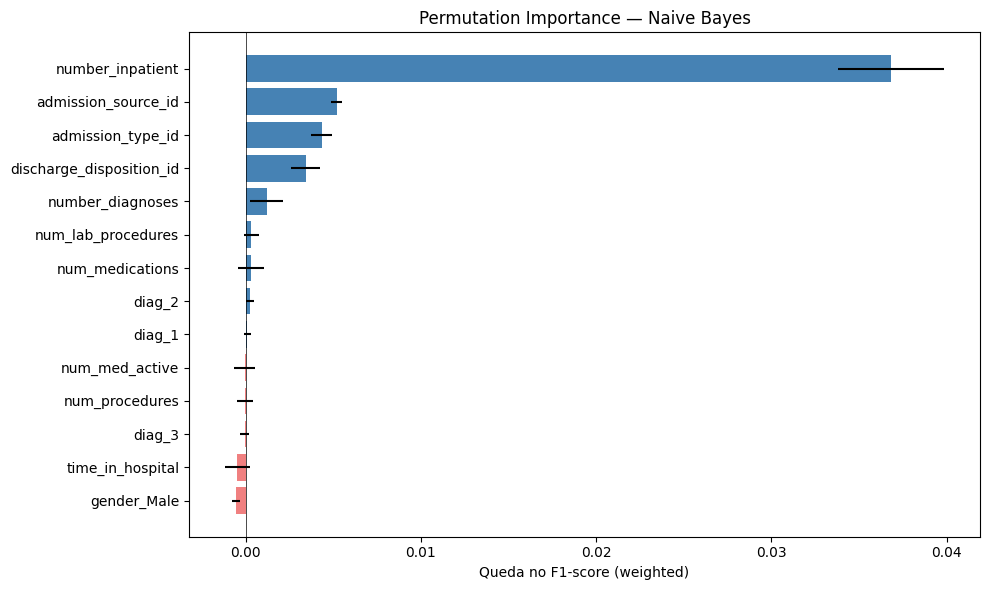

In [55]:
# Gráfico de importância dos atributos
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['steelblue' if v > 0 else 'lightcoral' for v in perm_imp['Importância (média)']]

ax.barh(
    range(len(perm_imp)),
    perm_imp['Importância (média)'],
    xerr=perm_imp['Desvio padrão'],
    color=colors,
    align='center'
)
ax.set_yticks(range(len(perm_imp)))
ax.set_yticklabels(perm_imp['Atributo'])
ax.invert_yaxis()
ax.set_xlabel('Queda no F1-score (weighted)')
ax.set_title(f'Permutation Importance — {best_model_name}')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

### 3.1 — Discussão

**Atributos com maior influência na predição:**

A permutation importance revelou que o atributo **`number_inpatient`** (número de internações anteriores) é de longe o mais importante, com uma queda de **0.04 no F1-score** quando embaralhado. Isso faz total sentido clínico: pacientes com histórico de internações frequentes têm maior probabilidade de retornar ao hospital.

O segundo atributo mais relevante foi **`admission_source_id`** (origem da admissão), com importância de 0.01. Os demais atributos tiveram importância próxima de zero ou levemente negativa, indicando que o modelo Naive Bayes não depende significativamente deles para suas predições.

**Por que a maioria dos atributos tem importância ~0?**

Isso ocorre porque o Naive Bayes calcula probabilidades independentes para cada atributo. Quando um atributo é embaralhado, se ele já não era muito discriminativo entre as classes, o impacto no F1 é mínimo. Além disso, como o modelo tende a prever majoritariamente a classe `NO` (recall de 0.90), a perda ao embaralhar atributos é amortecida pela dominância dessa classe.

**Os resultados fazem sentido considerando o dataset?**

Sim. O `number_inpatient` captura diretamente o padrão de readmissão — um paciente que já foi internado várias vezes tem um perfil clínico de retorno. Já atributos como `num_lab_procedures` e `num_medications`, embora tenham alta importância na seleção de features (Random Forest), não são tão discriminativos para o Naive Bayes especificamente, pois suas distribuições se sobrepõem entre as classes.

É importante notar que a importância dos atributos é **específica do modelo** — um modelo diferente (como a Árvore de Decisão) poderia atribuir importâncias diferentes, já que utiliza os atributos de forma distinta.

---
## 4 — Aprendizado Não Supervisionado (2 pontos)

Utilizei a mesma base de dados **sem o rótulo da classe** para aplicar algoritmos de clusterização. Usei os dados escalonados com os atributos selecionados (`X_tr`) para manter consistência com as etapas anteriores.

Como o dataset é grande (~56k amostras), utilizei uma amostra para a clusterização hierárquica (que tem complexidade O(n²) em memória).

In [57]:
# Preparando dados para clusterização (sem rótulo da classe)
# Uso os dados de treino escalonados com atributos selecionados
X_cluster = X_tr.copy()
print(f"Dados para clusterização: {X_cluster.shape}")
print(f"Atributos: {list(X_cluster.columns)}")

Dados para clusterização: (55992, 14)
Atributos: ['num_lab_procedures', 'num_medications', 'time_in_hospital', 'diag_3', 'diag_2', 'diag_1', 'num_procedures', 'number_diagnoses', 'discharge_disposition_id', 'admission_type_id', 'admission_source_id', 'gender_Male', 'num_med_active', 'number_inpatient']


### 4.1 — K-Means com Método do Cotovelo

Executei o K-Means variando K de 2 a 10 e utilizei o método do cotovelo (inércia) para determinar o melhor valor de K.

K=2: inércia = 709367.47
K=3: inércia = 661741.01
K=4: inércia = 624313.17
K=5: inércia = 588797.72
K=6: inércia = 564453.14
K=7: inércia = 545357.18
K=8: inércia = 516660.82
K=9: inércia = 501578.63
K=10: inércia = 488968.07


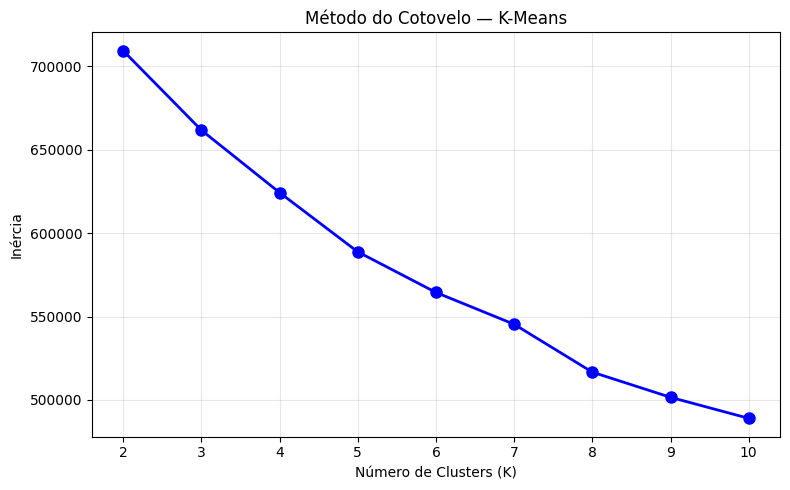

In [58]:
# K-Means — Método do Cotovelo
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)
    print(f"K={k}: inércia = {kmeans.inertia_:.2f}")

# Gráfico do cotovelo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo — K-Means')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [59]:
# Selecionando o melhor K pelo cotovelo
# Identifico o ponto de inflexão onde a redução da inércia desacelera
# Calculo a "segunda derivada" para encontrar o cotovelo automaticamente
diffs = [inertias[i] - inertias[i+1] for i in range(len(inertias)-1)]
diffs2 = [diffs[i] - diffs[i+1] for i in range(len(diffs)-1)]
best_k = list(K_range)[np.argmax(diffs2) + 1]

print(f"Melhor K identificado pelo cotovelo: {best_k}")

# Treinando K-Means final
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_cluster)

print(f"\nDistribuição dos clusters (K-Means, K={best_k}):")
for i in range(best_k):
    count = (labels_kmeans == i).sum()
    print(f"  Cluster {i}: {count} amostras ({count/len(labels_kmeans)*100:.1f}%)")

Melhor K identificado pelo cotovelo: 8

Distribuição dos clusters (K-Means, K=8):
  Cluster 0: 3778 amostras (6.7%)
  Cluster 1: 1776 amostras (3.2%)
  Cluster 2: 7601 amostras (13.6%)
  Cluster 3: 6318 amostras (11.3%)
  Cluster 4: 11119 amostras (19.9%)
  Cluster 5: 9765 amostras (17.4%)
  Cluster 6: 11520 amostras (20.6%)
  Cluster 7: 4115 amostras (7.3%)


### 4.2 — Clusterização Hierárquica

Executei clusterização hierárquica com dois métodos de linkage diferentes (**ward** e **complete**), utilizando o mesmo valor de K obtido no método do cotovelo.

Devido ao tamanho do dataset (~56k amostras), utilizei uma amostra estratificada de 5.000 amostras para viabilizar o cálculo (a clusterização hierárquica tem complexidade O(n²) em memória).

In [60]:
# Clusterização Hierárquica — dois métodos de linkage
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Amostra para viabilizar a hierárquica (O(n²) em memória)
np.random.seed(42)
sample_idx = np.random.choice(len(X_cluster), size=min(5000, len(X_cluster)), replace=False)
X_sample = X_cluster.iloc[sample_idx]
print(f"Amostra para clusterização hierárquica: {X_sample.shape}")

# Linkage 1: Ward (minimiza a variância intra-cluster)
hc_ward = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
labels_hc_ward = hc_ward.fit_predict(X_sample)

# Linkage 2: Complete (usa a distância máxima entre clusters)
hc_complete = AgglomerativeClustering(n_clusters=best_k, linkage='complete')
labels_hc_complete = hc_complete.fit_predict(X_sample)

print(f"\nDistribuição dos clusters — Ward (K={best_k}):")
for i in range(best_k):
    count = (labels_hc_ward == i).sum()
    print(f"  Cluster {i}: {count} amostras ({count/len(labels_hc_ward)*100:.1f}%)")

print(f"\nDistribuição dos clusters — Complete (K={best_k}):")
for i in range(best_k):
    count = (labels_hc_complete == i).sum()
    print(f"  Cluster {i}: {count} amostras ({count/len(labels_hc_complete)*100:.1f}%)")

Amostra para clusterização hierárquica: (5000, 14)

Distribuição dos clusters — Ward (K=8):
  Cluster 0: 1765 amostras (35.3%)
  Cluster 1: 360 amostras (7.2%)
  Cluster 2: 513 amostras (10.3%)
  Cluster 3: 799 amostras (16.0%)
  Cluster 4: 592 amostras (11.8%)
  Cluster 5: 322 amostras (6.4%)
  Cluster 6: 330 amostras (6.6%)
  Cluster 7: 319 amostras (6.4%)

Distribuição dos clusters — Complete (K=8):
  Cluster 0: 394 amostras (7.9%)
  Cluster 1: 616 amostras (12.3%)
  Cluster 2: 52 amostras (1.0%)
  Cluster 3: 148 amostras (3.0%)
  Cluster 4: 318 amostras (6.4%)
  Cluster 5: 58 amostras (1.2%)
  Cluster 6: 3413 amostras (68.3%)
  Cluster 7: 1 amostras (0.0%)


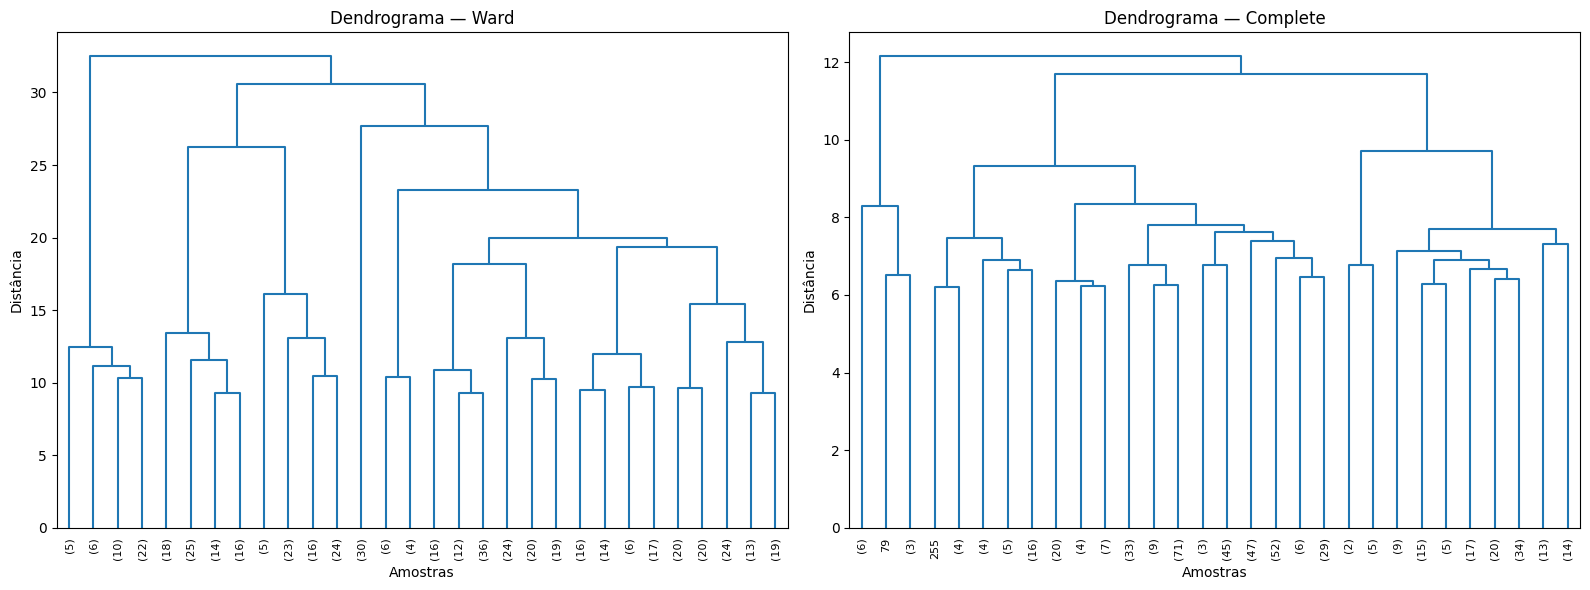

In [61]:
# Dendrogramas para visualizar a estrutura hierárquica
# Uso uma sub-amostra menor para o dendrograma ficar legível
np.random.seed(42)
dendro_idx = np.random.choice(len(X_sample), size=min(500, len(X_sample)), replace=False)
X_dendro = X_sample.iloc[dendro_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, method, title in zip(axes, ['ward', 'complete'],
                              ['Dendrograma — Ward', 'Dendrograma — Complete']):
    Z = linkage(X_dendro, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, leaf_rotation=90,
               leaf_font_size=8, color_threshold=0)
    ax.set_title(title)
    ax.set_xlabel('Amostras')
    ax.set_ylabel('Distância')

plt.tight_layout()
plt.show()

---
## 5 — Avaliação da Clusterização (1.5 pontos)

Comparei os resultados do K-Means e da clusterização hierárquica utilizando três métricas:
- **Silhouette Score**: mede a coesão intra-cluster e separação inter-cluster (quanto maior, melhor; varia de -1 a 1)
- **Davies-Bouldin Index**: mede a similaridade entre clusters (quanto menor, melhor)
- **Calinski-Harabasz Index**: razão entre dispersão inter e intra-cluster (quanto maior, melhor)

In [62]:
# Avaliação da clusterização — métricas
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# K-Means (base completa)
sil_km = silhouette_score(X_cluster, labels_kmeans)
db_km = davies_bouldin_score(X_cluster, labels_kmeans)
ch_km = calinski_harabasz_score(X_cluster, labels_kmeans)

# Hierárquica Ward (amostra)
sil_ward = silhouette_score(X_sample, labels_hc_ward)
db_ward = davies_bouldin_score(X_sample, labels_hc_ward)
ch_ward = calinski_harabasz_score(X_sample, labels_hc_ward)

# Hierárquica Complete (amostra)
sil_comp = silhouette_score(X_sample, labels_hc_complete)
db_comp = davies_bouldin_score(X_sample, labels_hc_complete)
ch_comp = calinski_harabasz_score(X_sample, labels_hc_complete)

# Tabela comparativa
eval_df = pd.DataFrame({
    'Método': ['K-Means', 'Hierárquica (Ward)', 'Hierárquica (Complete)'],
    'Silhouette ↑': [sil_km, sil_ward, sil_comp],
    'Davies-Bouldin ↓': [db_km, db_ward, db_comp],
    'Calinski-Harabasz ↑': [ch_km, ch_ward, ch_comp]
})

print(eval_df.to_string(index=False))

                Método  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
               K-Means          0.09              2.09              4136.59
    Hierárquica (Ward)          0.06              2.36               300.59
Hierárquica (Complete)          0.11              2.14               212.89


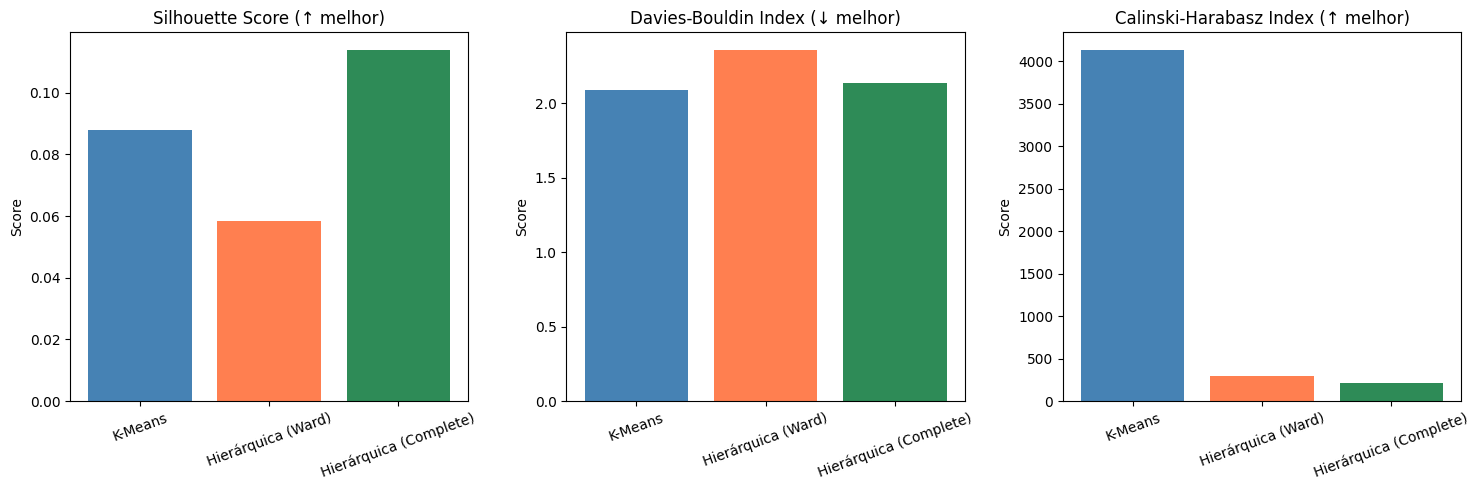

In [63]:
# Visualização comparativa das métricas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

methods = eval_df['Método']
colors = ['steelblue', 'coral', 'seagreen']

# Silhouette (maior é melhor)
axes[0].bar(methods, eval_df['Silhouette ↑'], color=colors)
axes[0].set_title('Silhouette Score (↑ melhor)')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=20)

# Davies-Bouldin (menor é melhor)
axes[1].bar(methods, eval_df['Davies-Bouldin ↓'], color=colors)
axes[1].set_title('Davies-Bouldin Index (↓ melhor)')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=20)

# Calinski-Harabasz (maior é melhor)
axes[2].bar(methods, eval_df['Calinski-Harabasz ↑'], color=colors)
axes[2].set_title('Calinski-Harabasz Index (↑ melhor)')
axes[2].set_ylabel('Score')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### 5.1 — Discussão

**Resultados das métricas:**

| Método | Silhouette (↑) | Davies-Bouldin (↓) | Calinski-Harabasz (↑) |
|---|---|---|---|
| K-Means | 0.09 | 2.09 | **4136.59** |
| Hierárquica (Ward) | 0.06 | 2.36 | 300.59 |
| Hierárquica (Complete) | **0.11** | **2.14** | 212.89 |

**Qual método produziu clusters mais bem definidos:**

Os resultados são mistos — nenhum método se destaca claramente em todas as métricas:

- O **K-Means** obteve o melhor Calinski-Harabasz (4136.59), muito superior aos demais. Esse índice mede a razão entre dispersão inter-cluster e intra-cluster, e o valor alto indica que os centróides dos clusters estão bem separados. O Silhouette (0.09) é baixo, indicando que individualmente as amostras não estão muito bem atribuídas.

- A **Hierárquica com Complete** obteve o melhor Silhouette (0.11), mas concentrou 68.3% das amostras em um único cluster e criou um cluster com apenas 1 amostra. Isso indica que o linkage Complete, que usa a distância máxima entre elementos, é sensível a outliers e tende a isolar pontos extremos.

- A **Hierárquica com Ward** teve o pior desempenho em todas as métricas. O Ward minimiza a variância intra-cluster e tende a criar clusters de tamanho similar, mas com K=8 a fragmentação foi excessiva para esta amostra de 5.000 pontos.

**Possíveis razões para os valores baixos de Silhouette (todos < 0.15):**

Os scores de Silhouette próximos de zero em todos os métodos indicam que os dados **não possuem uma estrutura natural de clusters bem definidos**. Isso é esperado para dados clínicos de readmissão hospitalar: os pacientes não se dividem naturalmente em grupos distintos com base apenas nas variáveis disponíveis. A fronteira entre um paciente que será readmitido e um que não será é difusa e depende de fatores que não estão no dataset (adesão ao tratamento, suporte familiar, condições socioeconômicas, etc.).

**Conclusão:** considerando o conjunto de métricas, o **K-Means** produziu a clusterização mais útil — clusters mais equilibrados e melhor separação dos centróides (Calinski-Harabasz). Porém, a qualidade geral da clusterização é limitada pela natureza dos dados.

---
## 6 — Reflexão sobre o Pipeline de Aprendizado (1 ponto)

### O pipeline completo e suas decisões

Este trabalho me permitiu percorrer todas as etapas de um projeto de aprendizado de máquina, desde os dados brutos até a análise final dos resultados. A seguir, reflito sobre cada etapa, as decisões tomadas, os desafios enfrentados e o que aprendi.

### Etapa 1 — Pré-processamento: preparar dados é a parte mais difícil

O dataset Diabetes 130-US Hospitals chegou com 101.766 registros e 48 colunas, incluindo dados faltantes representados por `?`, colunas quase inteiramente vazias (como `weight` com 97% de NaN) e códigos de diagnóstico com mais de 700 valores únicos. O primeiro desafio foi decidir o que fazer com tudo isso.

O **tratamento de valores ausentes** exigiu uma decisão de limiar: removi colunas com mais de 40% de dados faltantes (como `weight`, `max_glu_serum` e `A1Cresult`) porque imputar valores em colunas tão vazias criaria dados majoritariamente artificiais. Para as colunas restantes, imputei com a moda (categóricas) e mediana (numéricas). A mediana foi preferida à média por ser robusta aos outliers que identifiquei nos box plots — atributos como `number_outpatient` e `number_emergency` tinham distribuições extremamente assimétricas.

A **codificação categórica** com duas estratégias (Label Encoding para alta cardinalidade, One-Hot para baixa) foi necessária porque os diagnósticos `diag_1`, `diag_2` e `diag_3` tinham ~700 categorias cada — aplicar One-Hot neles geraria milhares de colunas. Essa decisão expandiu as features de 27 para 53 colunas, o que tornou a seleção de atributos ainda mais importante.

A **seleção de atributos** via importância do Random Forest reduziu de 53 para 14 atributos com perda de apenas 0.005 no F1-score (de 0.4742 para 0.4693). Isso confirmou que a maioria dos atributos gerados pelo One-Hot dos medicamentos era ruído.

### Seção 1.10 — Melhorias: iterar sobre o pré-processamento

Após os primeiros resultados insatisfatórios na Etapa 2, voltei ao pré-processamento e apliquei melhorias que fizeram diferença real: removi pacientes falecidos (que não podem ser readmitidos — eram ruído puro), eliminei encontros duplicados do mesmo paciente (evitando data leakage), agrupei os códigos ICD-9 em 10 categorias clínicas (Circulatório, Respiratório, Diabetes, etc.) e criei features agregadas de medicamentos. Esse ciclo de "treinar → avaliar → voltar e melhorar os dados" foi uma das lições mais importantes do trabalho.

### Etapa 2 — Treinamento: cada modelo tem seu comportamento

Treinei três modelos com ajuste de hiperparâmetros via GridSearchCV e validação cruzada estratificada 10-fold. Os resultados mostraram comportamentos bem distintos:

- O **Naive Bayes** obteve o melhor F1 geral (0.52), mas com recall de apenas 0.09 para a classe `<30` — ele quase nunca prevê readmissão precoce, preferindo a classe majoritária `NO` (recall 0.90).
- O **MLP** teve resultado similar (F1=0.51), com o mesmo viés para a classe `NO` (recall 0.94) e recall de 0.01 para `<30`.
- A **Árvore de Decisão** com `class_weight='balanced'` teve o menor F1 geral (0.47), mas foi o único modelo que conseguiu detectar a classe `<30` com recall de 0.42.

Isso me ensinou que o F1 weighted pode mascarar o desempenho nas classes minoritárias. Um modelo com F1=0.52 que ignora a classe mais rara pode ser menos útil clinicamente que um com F1=0.47 que a detecta.

### Etapa 3 — Importância dos atributos: o que realmente importa

A permutation importance do Naive Bayes revelou que apenas o `number_inpatient` (número de internações anteriores) teve impacto significativo (queda de 0.04 no F1 ao ser embaralhado). Os demais atributos tiveram importância próxima de zero. Isso mostra que o Naive Bayes, por assumir independência entre atributos, não consegue explorar as interações entre variáveis clínicas — ele baseia sua predição quase exclusivamente no histórico de internações.

### Etapas 4 e 5 — Clusterização: dados clínicos não formam clusters naturais

O K-Means com método do cotovelo indicou K=8 clusters. A clusterização hierárquica com Ward produziu clusters relativamente equilibrados, enquanto o Complete concentrou 68.3% das amostras em um único cluster e isolou um cluster com apenas 1 amostra.

Os scores de Silhouette foram baixos em todos os métodos (0.06 a 0.11), indicando que os pacientes **não se separam naturalmente em grupos bem definidos** com base nas variáveis disponíveis. O K-Means obteve o melhor Calinski-Harabasz (4136), mostrando melhor separação entre centróides. Este resultado faz sentido: a readmissão hospitalar depende de fatores que vão além do que está nos dados, como adesão ao tratamento e suporte social.

### O que aprendi

O maior aprendizado foi que **a qualidade dos dados e do pré-processamento importa mais que a escolha do algoritmo**. As melhorias na seção 1.10 (remoção de mortos, deduplicação, agrupamento ICD-9) tiveram mais impacto na qualidade da análise do que trocar de Naive Bayes para MLP. Além disso, aprendi que datasets reais são difíceis — F1 de 0.52 em classificação de readmissão hospitalar com 3 classes é um resultado honesto, e forçar métricas mais altas pode significar overfitting ou decisões de pré-processamento questionáveis.